<style>
h1, h1 *, 
h2, h2 *, 
h3, h3 *, 
h4, h4 *, 
h5, h5 *, 
h6, h6 * {
  font-family: "Times New Roman", Times, serif !important;
}
</style>

## **Algorithmic Trading - Part 2**

---

In [1]:
import sys
!{sys.executable} -m pip install yfinance

In [2]:
import sys
!{sys.executable} -m pip install datetime

In [3]:
import numpy as np
import seaborn as sns
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from datetime import datetime
from matplotlib import rcParams
%matplotlib inline
plt.style.use('ggplot')
rcParams['font.family'] = 'Times New Roman'
pd.set_option('display.max_columns', None)

In [4]:
aapl_df = yf.download('AAPL', start = '2016-01-01', 
                      end = datetime.today().strftime('%Y-%m-%d'), auto_adjust = False)
aapl_df

[*********************100%***********************]  1 of 1 completed


Price,Adj Close,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,,
2016-01-04,23.709105,26.337500,26.342501,25.500000,25.652500,270597600
2016-01-05,23.114965,25.677500,26.462500,25.602501,26.437500,223164000
2016-01-06,22.662617,25.174999,25.592501,24.967501,25.139999,273829600
2016-01-07,21.706152,24.112499,25.032499,24.107500,24.670000,324377600
2016-01-08,21.820929,24.240000,24.777500,24.190001,24.637501,283192000
...,...,...,...,...,...,...
2026-07-16,333.260010,333.260010,334.679993,326.790009,328.010010,62970600
2026-07-17,333.739990,333.739990,334.989990,329.000000,331.980011,63407100


In [5]:
aapl_df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2652 entries, 2016-01-04 to 2026-07-22
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   (Adj Close, AAPL)  2652 non-null   float64
 1   (Close, AAPL)      2652 non-null   float64
 2   (High, AAPL)       2652 non-null   float64
 3   (Low, AAPL)        2652 non-null   float64
 4   (Open, AAPL)       2652 non-null   float64
 5   (Volume, AAPL)     2652 non-null   int64  
dtypes: float64(5), int64(1)
memory usage: 145.0 KB


In [6]:
aapl_df.shape

(2652, 6)

In [7]:
aapl_df.isnull().sum()

Price      Ticker
Adj Close  AAPL      0
Close      AAPL      0
High       AAPL      0
Low        AAPL      0
Open       AAPL      0
Volume     AAPL      0
dtype: int64

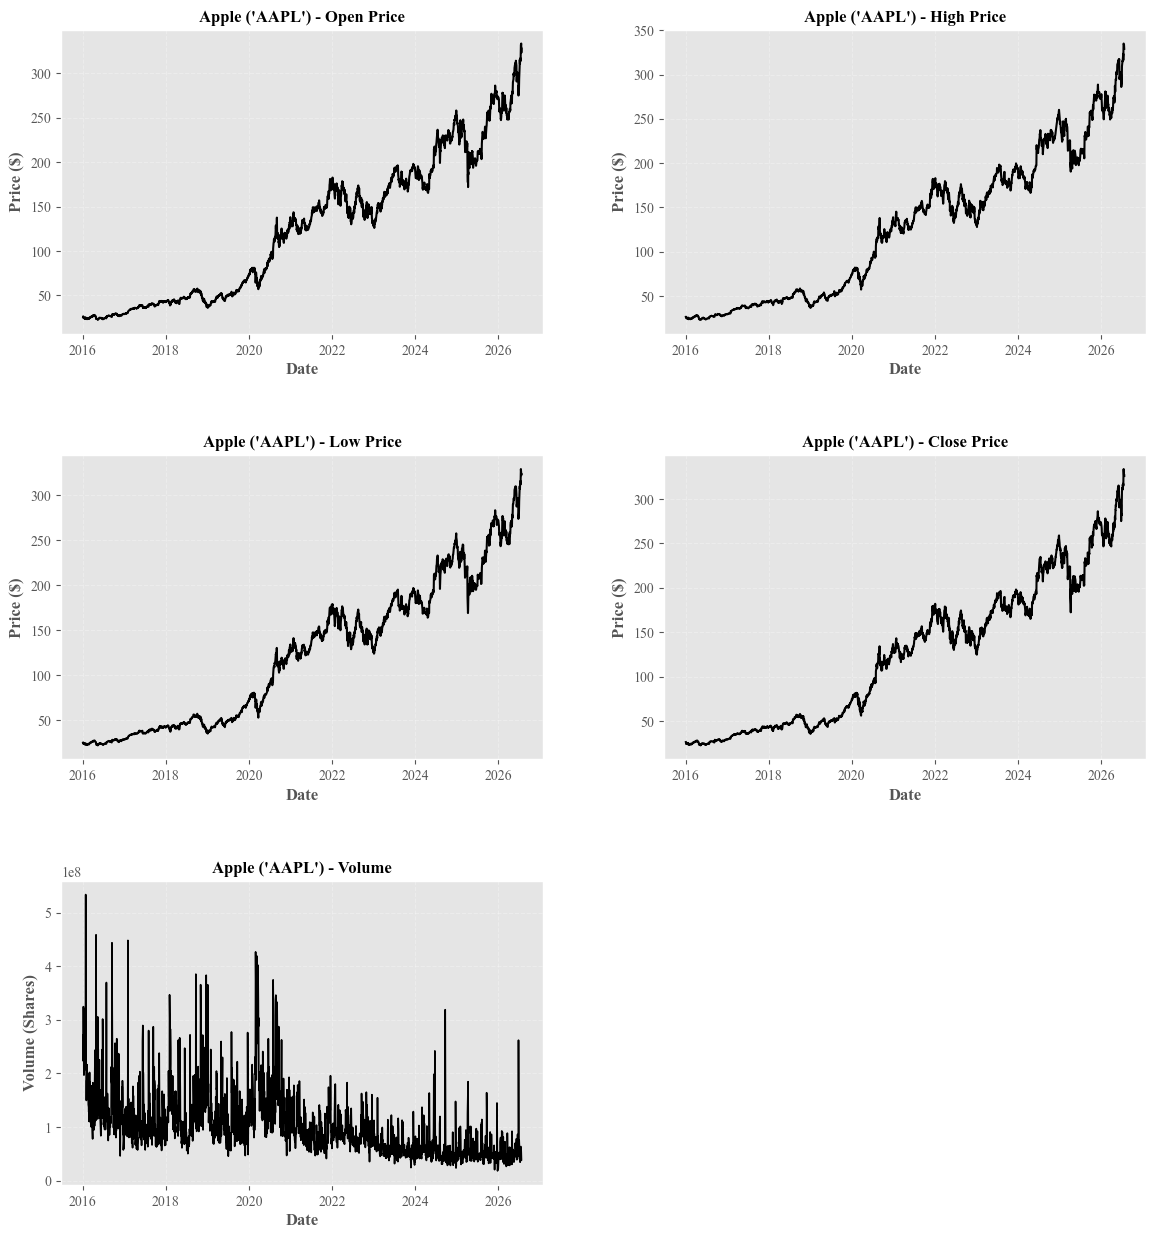

In [8]:
fig, axes = plt.subplots(3, 2, figsize = (14, 15))

axes[0, 0].plot(aapl_df.index, aapl_df['Open'], color = 'black', linewidth = 1.5)
axes[0, 0].set_title("Apple ('AAPL') - Open Price", fontweight = 'bold', fontsize = 12)
axes[0, 0].set_xlabel("Date", fontweight = 'bold')
axes[0, 0].set_ylabel("Price ($)", fontweight = 'bold')
axes[0, 0].grid(True, linestyle = '--', alpha = 0.3)

axes[0, 1].plot(aapl_df.index, aapl_df['High'], color = 'black', linewidth = 1.5)
axes[0, 1].set_title("Apple ('AAPL') - High Price", fontweight = 'bold', fontsize = 12)
axes[0, 1].set_xlabel("Date", fontweight = 'bold')
axes[0, 1].set_ylabel("Price ($)", fontweight = 'bold')
axes[0, 1].grid(True, linestyle = '--', alpha = 0.3)

axes[1, 0].plot(aapl_df.index, aapl_df['Low'], color = 'black', linewidth = 1.5)
axes[1, 0].set_title("Apple ('AAPL') - Low Price", fontweight = 'bold', fontsize = 12)
axes[1, 0].set_xlabel("Date", fontweight = 'bold')
axes[1, 0].set_ylabel("Price ($)", fontweight = 'bold')
axes[1, 0].grid(True, linestyle = '--', alpha = 0.3)

axes[1, 1].plot(aapl_df.index, aapl_df['Close'], color = 'black', linewidth = 1.5)
axes[1, 1].set_title("Apple ('AAPL') - Close Price", fontweight = 'bold', fontsize = 12)
axes[1, 1].set_xlabel("Date", fontweight = 'bold')
axes[1, 1].set_ylabel("Price ($)", fontweight = 'bold')
axes[1, 1].grid(True, linestyle = '--', alpha = 0.3)

fig.delaxes(axes[2, 1]) 
axes[2, 0].set_position([0.125, 0.1, 0.775, 0.2]) 

axes[2, 0].plot(aapl_df.index, aapl_df['Volume'], color = 'black', linewidth = 1.2)
axes[2, 0].set_title("Apple ('AAPL') - Volume", fontweight = 'bold', fontsize = 12)
axes[2, 0].set_xlabel("Date", fontweight = 'bold')
axes[2, 0].set_ylabel("Volume (Shares)", fontweight = 'bold')
axes[2, 0].grid(True, linestyle = '--', alpha = 0.3)

plt.subplots_adjust(hspace = 0.4, wspace = 0.25)
plt.show()

In [9]:
tickers = ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'TSLA', 'META', 'NFLX', 'NVDA', 'JPM', 'JNJ']
start_date = '2016-01-01'
end_date = datetime.today().strftime('%Y-%m-%d')
stocks = yf.download(tickers, start = start_date, end = end_date, auto_adjust = False)
stocks

[*********************100%***********************]  10 of 10 completed


Price        Adj Close                                                  \
Ticker            AAPL        AMZN       GOOGL         JNJ         JPM   
Date                                                                     
2016-01-04   23.709105   31.849501   37.638252   75.337547   48.184082   
2016-01-05   23.114965   31.689501   37.741833   75.652451   48.267376   
2016-01-06   22.662617   31.632500   37.632805   75.270088   47.570591   
2016-01-07   21.706152   30.396999   36.724354   74.392815   45.646870   
2016-01-08   21.820929   30.352501   36.224297   73.598076   44.624413   
...                ...         ...         ...         ...         ...   
2026-07-16  333.260010  249.889999  354.459991  249.970001  343.149994   
2026-07-17  333.739990  247.229996  346.769989  253.039993  341.100006   
2026-07-20  326.589996  249.990005  351.989990  248.820007  338.869995   
2026-07-21  327.739990  247.550003  347.149994  250.610001  345.230011   
2026-07-22  325.890015  244.850006  342.089996  255.630005  348.209991   

Price                                                                  \
Ticker            META        MSFT       NFLX        NVDA        TSLA   
Date                                                                    
2016-01-04  101.330154   47.770725  10.996000    0.788626   14.894000   
2016-01-05  101.835732   47.988647  10.766000    0.801295   14.895333   
2016-01-06  102.073631   47.116920  11.768000    0.768161   14.602667   
2016-01-07   97.067596   45.478073  11.456000    0.737708   14.376667   
2016-01-08   96.482727   45.617546  11.139000    0.721872   14.066667   
...                ...         ...        ...         ...         ...   
2026-07-16  664.539978  401.100006  74.349998  207.399994  391.059998   
2026-07-17  646.010010  393.820007  68.949997  202.809998  380.839996   
2026-07-20  645.849976  402.290009  67.599998  203.279999  369.570007   
2026-07-21  643.809998  397.750000  68.669998  207.289993  378.929993   
2026-07-22  627.169983  390.339996  68.529999  212.059998  374.010010   

Price            Close                                                  \
Ticker            AAPL        AMZN       GOOGL         JNJ         JPM   
Date                                                                     
2016-01-04   26.337500   31.849501   37.972000  100.480003   63.619999   
2016-01-05   25.677500   31.689501   38.076500  100.900002   63.730000   
2016-01-06   25.174999   31.632500   37.966499  100.389999   62.810001   
2016-01-07   24.112499   30.396999   37.049999   99.220001   60.270000   
2016-01-08   24.240000   30.352501   36.545502   98.160004   58.919998   
...                ...         ...         ...         ...         ...   
2026-07-16  333.260010  249.889999  354.459991  249.970001  343.149994   
2026-07-17  333.739990  247.229996  346.769989  253.039993  341.100006   
2026-07-20  326.589996  249.990005  351.989990  248.820007  338.869995   
2026-07-21  327.739990  247.550003  347.149994  250.610001  345.230011   
2026-07-22  325.890015  244.850006  342.089996  255.630005  348.209991   

Price                                                                  \
Ticker            META        MSFT       NFLX        NVDA        TSLA   
Date                                                                    
2016-01-04  102.220001   54.799999  10.996000    0.809250   14.894000   
2016-01-05  102.730003   55.049999  10.766000    0.822250   14.895333   
2016-01-06  102.970001   54.049999  11.768000    0.788250   14.602667   
2016-01-07   97.919998   52.169998  11.456000    0.757000   14.376667   
2016-01-08   97.330002   52.330002  11.139000    0.740750   14.066667   
...                ...         ...        ...         ...         ...   
2026-07-16  664.539978  401.100006  74.349998  207.399994  391.059998   
2026-07-17  646.010010  393.820007  68.949997  202.809998  380.839996   
2026-07-20  645.849976  402.290009  67.599998  203.279999  369.570007   
2026-07-21  643.809998  397

In [10]:
stocks.head()

Price       Adj Close                                                          \
Ticker           AAPL       AMZN      GOOGL        JNJ        JPM        META   
Date                                                                            
2016-01-04  23.709105  31.849501  37.638252  75.337547  48.184082  101.330154   
2016-01-05  23.114965  31.689501  37.741833  75.652451  48.267376  101.835732   
2016-01-06  22.662617  31.632500  37.632805  75.270088  47.570591  102.073631   
2016-01-07  21.706152  30.396999  36.724354  74.392815  45.646870   97.067596   
2016-01-08  21.820929  30.352501  36.224297  73.598076  44.624413   96.482727   

Price                                                   Close             \
Ticker           MSFT    NFLX      NVDA       TSLA       AAPL       AMZN   
Date                                                                       
2016-01-04  47.770725  10.996  0.788626  14.894000  26.337500  31.849501   
2016-01-05  47.988647  10.766  0.801295  14.895333  25.677500  31.689501   
2016-01-06  47.116920  11.768  0.768161  14.602667  25.174999  31.632500   
2016-01-07  45.478073  11.456  0.737708  14.376667  24.112499  30.396999   
2016-01-08  45.617546  11.139  0.721872  14.066667  24.240000  30.352501   

Price                                                                        \
Ticker          GOOGL         JNJ        JPM        META       MSFT    NFLX   
Date                                                                          
2016-01-04  37.972000  100.480003  63.619999  102.220001  54.799999  10.996   
2016-01-05  38.076500  100.900002  63.730000  102.730003  55.049999  10.766   
2016-01-06  37.966499  100.389999  62.810001  102.970001  54.049999  11.768   
2016-01-07  37.049999   99.220001  60.270000   97.919998  52.169998  11.456   
2016-01-08  36.545502   98.160004  58.919998   97.330002  52.330002  11.139   

Price                                High                                    \
Ticker         NVDA       TSLA       AAPL       AMZN      GOOGL         JNJ   
Date                                                                          
2016-01-04  0.80925  14.894000  26.342501  32.886002  38.110001  101.809998   
2016-01-05  0.82225  14.895333  26.462500  32.345501  38.459999  101.440002   
2016-01-06  0.78825  14.602667  25.592501  31.989500  38.286499  100.970001   
2016-01-07  0.75700  14.376667  25.032499  31.500000  37.765499  100.089996   
2016-01-08  0.74075  14.066667  24.777500  31.207001  37.506001   99.940002   

Price                                                                     \
Ticker            JPM        META       MSFT    NFLX     NVDA       TSLA   
Date                                                                       
2016-01-04  64.059998  102.239998  54.799999  11.000  0.81450  15.425333   
2016-01-05  64.129997  103.709999  55.389999  11.058  0.83600  15.126000   
2016-01-06  63.130001  103.769997  54.400002  11.791  0.81250  14.670000   
2016-01-07  62.000000  101.430000  53.490002  12.218  0.77375  14.562667   
2016-01-08  61.270000  100.500000  53.279999  11.772  0.76750  14.696000   

Price             Low                                               \
Ticker           AAPL       AMZN      GOOGL         JNJ        JPM   
Date                                                                 
2016-01-04  25.500000  31.375500  37.376999   99.449997  63.009998   
2016-01-05  25.602501  31.382500  37.782501  100.570000  63.040001   
2016-01-06  24.967501  31.015499  37.400002   99.599998  62.340000   
2016-01-07  24.107500  30.260500  36.764000   98.879997  60.080002   
2016-01-08  24.190001  30.299999  36.445999   97.849998  58.849998   

Price                                                               Open  \
Ticker            META       MSFT    NFLX     NVDA       TSLA       AAPL   
Date                                                                       
2016-01-04   99.750000  53.389999  10.521  0.80100  14.600000  25.652500   
20

In [11]:
stocks.tail()

Price        Adj Close                                                  \
Ticker            AAPL        AMZN       GOOGL         JNJ         JPM   
Date                                                                     
2026-07-16  333.260010  249.889999  354.459991  249.970001  343.149994   
2026-07-17  333.739990  247.229996  346.769989  253.039993  341.100006   
2026-07-20  326.589996  249.990005  351.989990  248.820007  338.869995   
2026-07-21  327.739990  247.550003  347.149994  250.610001  345.230011   
2026-07-22  325.890015  244.850006  342.089996  255.630005  348.209991   

Price                                                                  \
Ticker            META        MSFT       NFLX        NVDA        TSLA   
Date                                                                    
2026-07-16  664.539978  401.100006  74.349998  207.399994  391.059998   
2026-07-17  646.010010  393.820007  68.949997  202.809998  380.839996   
2026-07-20  645.849976  402.290009  67.599998  203.279999  369.570007   
2026-07-21  643.809998  397.750000  68.669998  207.289993  378.929993   
2026-07-22  627.169983  390.339996  68.529999  212.059998  374.010010   

Price            Close                                                  \
Ticker            AAPL        AMZN       GOOGL         JNJ         JPM   
Date                                                                     
2026-07-16  333.260010  249.889999  354.459991  249.970001  343.149994   
2026-07-17  333.739990  247.229996  346.769989  253.039993  341.100006   
2026-07-20  326.589996  249.990005  351.989990  248.820007  338.869995   
2026-07-21  327.739990  247.550003  347.149994  250.610001  345.230011   
2026-07-22  325.890015  244.850006  342.089996  255.630005  348.209991   

Price                                                                  \
Ticker            META        MSFT       NFLX        NVDA        TSLA   
Date                                                                    
2026-07-16  664.539978  401.100006  74.349998  207.399994  391.059998   
2026-07-17  646.010010  393.820007  68.949997  202.809998  380.839996   
2026-07-20  645.849976  402.290009  67.599998  203.279999  369.570007   
2026-07-21  643.809998  397.750000  68.669998  207.289993  378.929993   
2026-07-22  627.169983  390.339996  68.529999  212.059998  374.010010   

Price             High                                                  \
Ticker            AAPL        AMZN       GOOGL         JNJ         JPM   
Date                                                                     
2026-07-16  334.679993  258.079987  375.269989  253.550003  349.339996   
2026-07-17  334.989990  250.240005  348.519989  255.660004  346.130005   
2026-07-20  333.709991  252.889999  359.679993  254.179993  344.260010   
2026-07-21  329.600006  249.339996  351.320007  251.339996  345.739990   
2026-07-22  329.000000  248.449997  349.940002  256.290009  349.070007   

Price                                                                  \
Ticker            META        MSFT       NFLX        NVDA        TSLA   
Date                                                                    
2026-07-16  681.900024  405.989990  74.680000  211.080002  395.309998   
2026-07-17  652.200012  398.390015  69.489998  206.649994  385.690002   
2026-07-20  653.299988  403.179993  68.379997  207.740005  386.609985   
2026-07-21  655.880005  401.470001  68.750000  208.649994  384.070007   
2026-07-22  649.000000  401.000000  70.570000  214.389999  380.170013   

Price              Low                                                  \
Ticker            AAPL        AMZN       GOOGL         JNJ         JPM   
Date                                                                     
2026-07-16  326.790009  248.000000  352.299988  246.300003  341.109985   
2026-07-17  329.000000  243.589996  341.359985  251.949997  335.049988   
2026-07-20  323.679993  248.000000  350.519989  248.630005  337.369995   
2026-07-21  322.220001

In [12]:
stocks.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2652 entries, 2016-01-04 to 2026-07-22
Data columns (total 60 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   (Adj Close, AAPL)   2652 non-null   float64
 1   (Adj Close, AMZN)   2652 non-null   float64
 2   (Adj Close, GOOGL)  2652 non-null   float64
 3   (Adj Close, JNJ)    2652 non-null   float64
 4   (Adj Close, JPM)    2652 non-null   float64
 5   (Adj Close, META)   2652 non-null   float64
 6   (Adj Close, MSFT)   2652 non-null   float64
 7   (Adj Close, NFLX)   2652 non-null   float64
 8   (Adj Close, NVDA)   2652 non-null   float64
 9   (Adj Close, TSLA)   2652 non-null   float64
 10  (Close, AAPL)       2652 non-null   float64
 11  (Close, AMZN)       2652 non-null   float64
 12  (Close, GOOGL)      2652 non-null   float64
 13  (Close, JNJ)        2652 non-null   float64
 14  (Close, JPM)        2652 non-null   float64
 15  (Close, META)       2652 non-null   f

In [13]:
stocks.to_csv('Algorithmic Trading (2) - Dataset')

In [14]:
stocks = pd.read_csv('Algorithmic Trading (2) - Dataset', header = [0, 1])

In [15]:
stocks

Price   Adj Close                                                  \
          Ticker        AAPL        AMZN       GOOGL         JNJ         JPM   
0           Date         NaN         NaN         NaN         NaN         NaN   
1     2016-01-04   23.709105   31.849501   37.638252   75.337547   48.184082   
2     2016-01-05   23.114965   31.689501   37.741833   75.652451   48.267376   
3     2016-01-06   22.662617   31.632500   37.632805   75.270088   47.570591   
4     2016-01-07   21.706152   30.396999   36.724354   74.392815   45.646870   
...          ...         ...         ...         ...         ...         ...   
2648  2026-07-16  333.260010  249.889999  354.459991  249.970001  343.149994   
2649  2026-07-17  333.739990  247.229996  346.769989  253.039993  341.100006   
2650  2026-07-20  326.589996  249.990005  351.989990  248.820007  338.869995   
2651  2026-07-21  327.739990  247.550003  347.149994  250.610001  345.230011   
2652  2026-07-22  325.890015  244.850006  342.089996  255.630005  348.209991   

                                                                      Close  \
            META        MSFT       NFLX        NVDA        TSLA        AAPL   
0            NaN         NaN        NaN         NaN         NaN         NaN   
1     101.330154   47.770725  10.996000    0.788626   14.894000   26.337500   
2     101.835732   47.988647  10.766000    0.801295   14.895333   25.677500   
3     102.073631   47.116920  11.768000    0.768161   14.602667   25.174999   
4      97.067596   45.478073  11.456000    0.737708   14.376667   24.112499   
...          ...         ...        ...         ...         ...         ...   
2648  664.539978  401.100006  74.349998  207.399994  391.059998  333.260010   
2649  646.010010  393.820007  68.949997  202.809998  380.839996  333.739990   
2650  645.849976  402.290009  67.599998  203.279999  369.570007  326.589996   
2651  643.809998  397.750000  68.669998  207.289993  378.929993  327.739990   
2652  627.169983  390.339996  68.529999  212.059998  374.010010  325.890015   

                                                                              \
            AMZN       GOOGL         JNJ         JPM        META        MSFT   
0            NaN         NaN         NaN         NaN         NaN         NaN   
1      31.849501   37.972000  100.480003   63.619999  102.220001   54.799999   
2      31.689501   38.076500  100.900002   63.730000  102.730003   55.049999   
3      31.632500   37.966499  100.389999   62.810001  102.970001   54.049999   
4      30.396999   37.049999   99.220001   60.270000   97.919998   52.169998   
...          ...         ...         ...         ...         ...         ...   
2648  249.889999  354.459991  249.970001  343.149994  664.539978  401.100006   
2649  247.229996  346.769989  253.039993  341.100006  646.010010  393.820007   
2650  249.990005  351.989990  248.820007  338.869995  645.849976  402.290009   
2651  247.550003  347.149994  250.610001  345.230011  643.809998  397.750000   
2652  244.850006  342.089996  255.630005  348.209991  627.169983  390.339996   

                                               High                          \
           NFLX        NVDA        TSLA        AAPL        AMZN       GOOGL   
0           NaN         NaN         NaN         NaN         NaN         NaN   
1     10.996000    0.809250   14.894000   26.342501   32.886002   38.110001   
2     10.766000    0.822250   14.895333   26.462500   32.345501   38.459999   
3     11.768000    0.788250   14.602667   25.592501   31.989500   38.286499   
4     11.456000    0.757000   14.376667   25.032499   31.500000   37.765499   
...         ...         ...         ...         ...         ...         ...   
2648  74.349998  207.399994  391.059998  334.679993  258.079987  375.269989   
2649  68.949997  202.809998  380.839996  334.989990  250.240005  348.519989   
2650  67.599998  203.279999  369.570007  333.709991  252.889999  359.679993   
2651  68.669998  207.289993  378

In [16]:
aapl = yf.Ticker('AAPL')
aapl_info = aapl.info
aapl_info

{'address1': 'One Apple Park Way',
 'city': 'Cupertino',
 'state': 'CA',
 'zip': '95014',
 'country': 'United States',
 'phone': '(408) 996-1010',
 'website': 'https://www.apple.com',
 'industry': 'Consumer Electronics',
 'industryKey': 'consumer-electronics',
 'industryDisp': 'Consumer Electronics',
 'sector': 'Technology',
 'sectorKey': 'technology',
 'sectorDisp': 'Technology',
 'longBusinessSummary': 'Apple Inc. designs, manufactures, and markets smartphones, personal computers, tablets, wearables, and accessories worldwide. The company offers iPhone, a line of smartphones; Mac, a line of personal computers; iPad, a line of multi-purpose tablets; and wearables, home, and accessories comprising AirPods, Apple Vision Pro, Apple TV, Apple Watch, Beats products, and HomePod, as well as Apple branded and third-party accessories. It also provides AppleCare support and cloud services; and operates various platforms, including the App Store that allows customers to discover and download ap

In [17]:
aapl_fundamental_df = pd.DataFrame([aapl_info])
aapl_fundamental_df['symbol'] = 'AAPL'
aapl_fundamental_df

,address1,city,state,zip,country,phone,website,industry,industryKey,industryDisp,sector,sectorKey,sectorDisp,longBusinessSummary,fullTimeEmployees,companyOfficers,auditRisk,boardRisk,compensationRisk,shareHolderRightsRisk,overallRisk,governanceEpochDate,compensationAsOfEpochDate,irWebsite,executiveTeam,maxAge,priceHint,previousClose,open,dayLow,dayHigh,regularMarketPreviousClose,regularMarketOpen,regularMarketDayLow,regularMarketDayHigh,dividendRate,dividendYield,exDividendDate,payoutRatio,fiveYearAvgDividendYield,beta,trailingPE,forwardPE,volume,regularMarketVolume,averageVolume,averageVolume10days,averageDailyVolume10Day,bid,ask,bidSize,askSize,marketCap,nonDilutedMarketCap,fiftyTwoWeekLow,fiftyTwoWeekHigh,allTimeHigh,allTimeLow,priceToSalesTrailing12Months,fiftyDayAverage,twoHundredDayAverage,trailingAnnualDividendRate,trailingAnnualDividendYield,currency,tradeable,enterpriseValue,profitMargins,floatShares,sharesOutstanding,sharesShort,sharesShortPriorMonth,sharesShortPreviousMonthDate,dateShortInterest,sharesPercentSharesOut,heldPercentInsiders,heldPercentInstitutions,shortRatio,shortPercentOfFloat,impliedSharesOutstanding,bookValue,priceToBook,lastFiscalYearEnd,nextFiscalYearEnd,mostRecentQuarter,earningsQuarterlyGrowth,netIncomeToCommon,trailingEps,forwardEps,pegRatio,lastSplitFactor,lastSplitDate,enterpriseToRevenue,enterpriseToEbitda,52WeekChange,SandP52WeekChange,lastDividendValue,lastDividendDate,quoteType,currentPrice,targetHighPrice,targetLowPrice,targetMeanPrice,targetMedianPrice,recommendationMean,recommendationKey,numberOfAnalystOpinions,totalCash,totalCashPerShare,ebitda,totalDebt,quickRatio,currentRatio,totalRevenue,debtToEquity,revenuePerShare,returnOnAssets,returnOnEquity,grossProfits,freeCashflow,operatingCashflow,earningsGrowth,revenueGrowth,grossMargins,ebitdaMargins,operatingMargins,financialCurrency,symbol,language,region,typeDisp,quoteSourceName,triggerable,customPriceAlertConfidence,marketState,corporateActions,regularMarketTime,exchange,messageBoardId,exchangeTimezoneName,exchangeTimezoneShortName,gmtOffSetMilliseconds,market,esgPopulated,regularMarketChangePercent,regularMarketPrice,shortName,longName,epsForward,epsCurrentYear,priceEpsCurrentYear,fiftyDayAverageChange,fiftyDayAverageChangePercent,twoHundredDayAverageChange,twoHundredDayAverageChangePercent,sourceInterval,exchangeDataDelayedBy,averageAnalystRating,cryptoTradeable,hasPrePostMarketData,firstTradeDateMilliseconds,regularMarketChange,regularMarketDayRange,fullExchangeName,averageDailyVolume3Month,fiftyTwoWeekLowChange,fiftyTwoWeekLowChangePercent,fiftyTwoWeekRange,fiftyTwoWeekHighChange,fiftyTwoWeekHighChangePercent,fiftyTwoWeekChangePercent,dividendDate,earningsTimestamp,earningsTimestampStart,earningsTimestampEnd,earningsCallTimestampStart,earningsCallTimestampEnd,isEarningsDateEstimate,epsTrailingTwelveMonths,displayName,trailingPegRatio
0,One Apple Park Way,Cupertino,CA,95014,United States,(408) 996-1010,https://www.apple.com,Consumer Electronics,consumer-electronics,Consumer Electronics,Technology,technology,Technology,"Apple Inc. designs, manufactures, and markets ...",166000,"[{'maxAge': 1, 'name': 'Mr. Timothy D. Cook', ...",2,1,7,1,1,1782864000,1767139200,http://investor.apple.com/,[],86400,2,325.89,321.73,319.35,323.3,325.89,321.73,319.35,323.3,1.08,0.33,1778457600,0.1259,0.5,1.097,38.980606,33.3629,10480039,10480346,55239508,48269410,48269410,321.54,323.48,3,3,4723306921984,4786462446840,201.5,334.99,334.99,0.049107,10.463036,304.8874,275.2806,1.04,0.003191,USD,False,4802666299392,0.27152,14662387495,14687356000,140526320,155886024,1780012800,1782777600,0.0096,0.0163,0.66504,2.11,0.0096,14687356000,7.26,44.296143,1758931200,1790467200,1774656000,0.194,122575003648,8.25,9.63915,2.64,4:1,1598832000,10.639,30.021,0.52456,0.178461,0.27,1778457600,EQUITY,321.6,400.0,215.0,318.25116,325.0,2.02128,buy,43,68507000832,4.664,159975997440,84710998016,0.906,1.07,451442016256,79.548,30.534,0.26229,1.41471,216070995968,101090746368,14022200

In [18]:
aapl_fundamental_df[['symbol']]

,symbol
0,AAPL


In [19]:
aapl_fundamental_df.columns

Index(['address1', 'city', 'state', 'zip', 'country', 'phone', 'website',
       'industry', 'industryKey', 'industryDisp',
       ...
       'dividendDate', 'earningsTimestamp', 'earningsTimestampStart',
       'earningsTimestampEnd', 'earningsCallTimestampStart',
       'earningsCallTimestampEnd', 'isEarningsDateEstimate',
       'epsTrailingTwelveMonths', 'displayName', 'trailingPegRatio'],
      dtype='object', length=180)

In [20]:
stocks = pd.read_csv('Algorithmic Trading (2) - Dataset', header = [0, 1], index_col = [0])
stocks

Price        Adj Close                                                  \
Ticker            AAPL        AMZN       GOOGL         JNJ         JPM   
Date                                                                     
2016-01-04   23.709105   31.849501   37.638252   75.337547   48.184082   
2016-01-05   23.114965   31.689501   37.741833   75.652451   48.267376   
2016-01-06   22.662617   31.632500   37.632805   75.270088   47.570591   
2016-01-07   21.706152   30.396999   36.724354   74.392815   45.646870   
2016-01-08   21.820929   30.352501   36.224297   73.598076   44.624413   
...                ...         ...         ...         ...         ...   
2026-07-16  333.260010  249.889999  354.459991  249.970001  343.149994   
2026-07-17  333.739990  247.229996  346.769989  253.039993  341.100006   
2026-07-20  326.589996  249.990005  351.989990  248.820007  338.869995   
2026-07-21  327.739990  247.550003  347.149994  250.610001  345.230011   
2026-07-22  325.890015  244.850006  342.089996  255.630005  348.209991   

Price                                                                  \
Ticker            META        MSFT       NFLX        NVDA        TSLA   
Date                                                                    
2016-01-04  101.330154   47.770725  10.996000    0.788626   14.894000   
2016-01-05  101.835732   47.988647  10.766000    0.801295   14.895333   
2016-01-06  102.073631   47.116920  11.768000    0.768161   14.602667   
2016-01-07   97.067596   45.478073  11.456000    0.737708   14.376667   
2016-01-08   96.482727   45.617546  11.139000    0.721872   14.066667   
...                ...         ...        ...         ...         ...   
2026-07-16  664.539978  401.100006  74.349998  207.399994  391.059998   
2026-07-17  646.010010  393.820007  68.949997  202.809998  380.839996   
2026-07-20  645.849976  402.290009  67.599998  203.279999  369.570007   
2026-07-21  643.809998  397.750000  68.669998  207.289993  378.929993   
2026-07-22  627.169983  390.339996  68.529999  212.059998  374.010010   

Price            Close                                                  \
Ticker            AAPL        AMZN       GOOGL         JNJ         JPM   
Date                                                                     
2016-01-04   26.337500   31.849501   37.972000  100.480003   63.619999   
2016-01-05   25.677500   31.689501   38.076500  100.900002   63.730000   
2016-01-06   25.174999   31.632500   37.966499  100.389999   62.810001   
2016-01-07   24.112499   30.396999   37.049999   99.220001   60.270000   
2016-01-08   24.240000   30.352501   36.545502   98.160004   58.919998   
...                ...         ...         ...         ...         ...   
2026-07-16  333.260010  249.889999  354.459991  249.970001  343.149994   
2026-07-17  333.739990  247.229996  346.769989  253.039993  341.100006   
2026-07-20  326.589996  249.990005  351.989990  248.820007  338.869995   
2026-07-21  327.739990  247.550003  347.149994  250.610001  345.230011   
2026-07-22  325.890015  244.850006  342.089996  255.630005  348.209991   

Price                                                                  \
Ticker            META        MSFT       NFLX        NVDA        TSLA   
Date                                                                    
2016-01-04  102.220001   54.799999  10.996000    0.809250   14.894000   
2016-01-05  102.730003   55.049999  10.766000    0.822250   14.895333   
2016-01-06  102.970001   54.049999  11.768000    0.788250   14.602667   
2016-01-07   97.919998   52.169998  11.456000    0.757000   14.376667   
2016-01-08   97.330002   52.330002  11.139000    0.740750   14.066667   
...                ...         ...        ...         ...         ...   
2026-07-16  664.539978  401.100006  74.349998  207.399994  391.059998   
2026-07-17  646.010010  393.820007  68.949997  202.809998  380.839996   
2026-07-20  645.849976  402.290009  67.599998  203.279999  369.570007   
2026-07-21  643.809998  397

In [21]:
stocks = pd.read_csv('Algorithmic Trading (2) - Dataset', header = [0, 1], index_col = [0], parse_dates = [0])
stocks

Price        Adj Close                                                  \
Ticker            AAPL        AMZN       GOOGL         JNJ         JPM   
Date                                                                     
2016-01-04   23.709105   31.849501   37.638252   75.337547   48.184082   
2016-01-05   23.114965   31.689501   37.741833   75.652451   48.267376   
2016-01-06   22.662617   31.632500   37.632805   75.270088   47.570591   
2016-01-07   21.706152   30.396999   36.724354   74.392815   45.646870   
2016-01-08   21.820929   30.352501   36.224297   73.598076   44.624413   
...                ...         ...         ...         ...         ...   
2026-07-16  333.260010  249.889999  354.459991  249.970001  343.149994   
2026-07-17  333.739990  247.229996  346.769989  253.039993  341.100006   
2026-07-20  326.589996  249.990005  351.989990  248.820007  338.869995   
2026-07-21  327.739990  247.550003  347.149994  250.610001  345.230011   
2026-07-22  325.890015  244.850006  342.089996  255.630005  348.209991   

Price                                                                  \
Ticker            META        MSFT       NFLX        NVDA        TSLA   
Date                                                                    
2016-01-04  101.330154   47.770725  10.996000    0.788626   14.894000   
2016-01-05  101.835732   47.988647  10.766000    0.801295   14.895333   
2016-01-06  102.073631   47.116920  11.768000    0.768161   14.602667   
2016-01-07   97.067596   45.478073  11.456000    0.737708   14.376667   
2016-01-08   96.482727   45.617546  11.139000    0.721872   14.066667   
...                ...         ...        ...         ...         ...   
2026-07-16  664.539978  401.100006  74.349998  207.399994  391.059998   
2026-07-17  646.010010  393.820007  68.949997  202.809998  380.839996   
2026-07-20  645.849976  402.290009  67.599998  203.279999  369.570007   
2026-07-21  643.809998  397.750000  68.669998  207.289993  378.929993   
2026-07-22  627.169983  390.339996  68.529999  212.059998  374.010010   

Price            Close                                                  \
Ticker            AAPL        AMZN       GOOGL         JNJ         JPM   
Date                                                                     
2016-01-04   26.337500   31.849501   37.972000  100.480003   63.619999   
2016-01-05   25.677500   31.689501   38.076500  100.900002   63.730000   
2016-01-06   25.174999   31.632500   37.966499  100.389999   62.810001   
2016-01-07   24.112499   30.396999   37.049999   99.220001   60.270000   
2016-01-08   24.240000   30.352501   36.545502   98.160004   58.919998   
...                ...         ...         ...         ...         ...   
2026-07-16  333.260010  249.889999  354.459991  249.970001  343.149994   
2026-07-17  333.739990  247.229996  346.769989  253.039993  341.100006   
2026-07-20  326.589996  249.990005  351.989990  248.820007  338.869995   
2026-07-21  327.739990  247.550003  347.149994  250.610001  345.230011   
2026-07-22  325.890015  244.850006  342.089996  255.630005  348.209991   

Price                                                                  \
Ticker            META        MSFT       NFLX        NVDA        TSLA   
Date                                                                    
2016-01-04  102.220001   54.799999  10.996000    0.809250   14.894000   
2016-01-05  102.730003   55.049999  10.766000    0.822250   14.895333   
2016-01-06  102.970001   54.049999  11.768000    0.788250   14.602667   
2016-01-07   97.919998   52.169998  11.456000    0.757000   14.376667   
2016-01-08   97.330002   52.330002  11.139000    0.740750   14.066667   
...                ...         ...        ...         ...         ...   
2026-07-16  664.539978  401.100006  74.349998  207.399994  391.059998   
2026-07-17  646.010010  393.820007  68.949997  202.809998  380.839996   
2026-07-20  645.849976  402.290009  67.599998  203.279999  369.570007   
2026-07-21  643.809998  397

In [22]:
stocks.columns

MultiIndex([('Adj Close',  'AAPL'),
            ('Adj Close',  'AMZN'),
            ('Adj Close', 'GOOGL'),
            ('Adj Close',   'JNJ'),
            ('Adj Close',   'JPM'),
            ('Adj Close',  'META'),
            ('Adj Close',  'MSFT'),
            ('Adj Close',  'NFLX'),
            ('Adj Close',  'NVDA'),
            ('Adj Close',  'TSLA'),
            (    'Close',  'AAPL'),
            (    'Close',  'AMZN'),
            (    'Close', 'GOOGL'),
            (    'Close',   'JNJ'),
            (    'Close',   'JPM'),
            (    'Close',  'META'),
            (    'Close',  'MSFT'),
            (    'Close',  'NFLX'),
            (    'Close',  'NVDA'),
            (    'Close',  'TSLA'),
            (     'High',  'AAPL'),
            (     'High',  'AMZN'),
            (     'High', 'GOOGL'),
            (     'High',   'JNJ'),
            (     'High',   'JPM'),
            (     'High',  'META'),
            (     'High',  'MSFT'),
            (     'High',  '

In [23]:
stocks.columns = stocks.columns.to_flat_index()
stocks.columns

Index([ ('Adj Close', 'AAPL'),  ('Adj Close', 'AMZN'), ('Adj Close', 'GOOGL'),
         ('Adj Close', 'JNJ'),   ('Adj Close', 'JPM'),  ('Adj Close', 'META'),
        ('Adj Close', 'MSFT'),  ('Adj Close', 'NFLX'),  ('Adj Close', 'NVDA'),
        ('Adj Close', 'TSLA'),      ('Close', 'AAPL'),      ('Close', 'AMZN'),
           ('Close', 'GOOGL'),       ('Close', 'JNJ'),       ('Close', 'JPM'),
            ('Close', 'META'),      ('Close', 'MSFT'),      ('Close', 'NFLX'),
            ('Close', 'NVDA'),      ('Close', 'TSLA'),       ('High', 'AAPL'),
             ('High', 'AMZN'),      ('High', 'GOOGL'),        ('High', 'JNJ'),
              ('High', 'JPM'),       ('High', 'META'),       ('High', 'MSFT'),
             ('High', 'NFLX'),       ('High', 'NVDA'),       ('High', 'TSLA'),
              ('Low', 'AAPL'),        ('Low', 'AMZN'),       ('Low', 'GOOGL'),
               ('Low', 'JNJ'),         ('Low', 'JPM'),        ('Low', 'META'),
              ('Low', 'MSFT'),        ('Low', 'NFLX'

In [24]:
stocks.head()

,"(Adj Close, AAPL)","(Adj Close, AMZN)","(Adj Close, GOOGL)","(Adj Close, JNJ)","(Adj Close, JPM)","(Adj Close, META)","(Adj Close, MSFT)","(Adj Close, NFLX)","(Adj Close, NVDA)","(Adj Close, TSLA)","(Close, AAPL)","(Close, AMZN)","(Close, GOOGL)","(Close, JNJ)","(Close, JPM)","(Close, META)","(Close, MSFT)","(Close, NFLX)","(Close, NVDA)","(Close, TSLA)","(High, AAPL)","(High, AMZN)","(High, GOOGL)","(High, JNJ)","(High, JPM)","(High, META)","(High, MSFT)","(High, NFLX)","(High, NVDA)","(High, TSLA)","(Low, AAPL)","(Low, AMZN)","(Low, GOOGL)","(Low, JNJ)","(Low, JPM)","(Low, META)","(Low, MSFT)","(Low, NFLX)","(Low, NVDA)","(Low, TSLA)","(Open, AAPL)","(Open, AMZN)","(Open, GOOGL)","(Open, JNJ)","(Open, JPM)","(Open, META)","(Open, MSFT)","(Open, NFLX)","(Open, NVDA)","(Open, TSLA)","(Volume, AAPL)","(Volume, AMZN)","(Volume, GOOGL)","(Volume, JNJ)","(Volume, JPM)","(Volume, META)","(Volume, MSFT)","(Volume, NFLX)","(Volume, NVDA)","(Volume, TSLA)"
Date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2016-01-04,23.709105,31.849501,37.638252,75.337547,48.184082,101.330154,47.770725,10.996,0.788626,14.894000,26.337500,31.849501,37.972000,100.480003,63.619999,102.220001,54.799999,10.996,0.80925,14.894000,26.342501,32.886002,38.110001,101.809998,64.059998,102.239998,54.799999,11.000,0.81450,15.425333,25.500000,31.375500,37.376999,99.449997,63.009998,99.750000,53.389999,10.521,0.80100,14.600000,25.652500,32.814499,38.110001,101.709999,63.950001,101.949997,54.320000,10.900,0.80725,15.381333,270597600,186290000,67382000,12722800,25393200,37912400,53778000,207948000,358076000,102406500
2016-01-05,23.114965,31.689501,37.741833,75.652451,48.267376,101.835732,47.988647,10.766,0.801295,14.895333,25.677500,31.689501,38.076500,100.900002,63.730000,102.730003,55.049999,10.766,0.82225,14.895333,26.462500,32.345501,38.459999,101.440002,64.129997,103.709999,55.389999,11.058,0.83600,15.126000,25.602501,31.382500,37.782501,100.570000,63.040001,101.669998,54.540001,10.585,0.81250,14.666667,26.437500,32.342999,38.205002,100.580002,63.700001,102.889999,54.930000,11.045,0.82450,15.090667,223164000,116452000,45216000,6467200,16566700,23258200,34079700,176646000,490272000,47802000
2016-01-06,22.662617,31.632500,37.632805,75.270088,47.570591,102.073631,47.116920,11.768,0.768161,14.602667,25.174999,31.632500,37.966499,100.389999,62.810001,102.970001,54.049999,11.768,0.78825,14.602667,25.592501,31.989500,38.286499,100.970001,63.130001,103.769997,54.400002,11.791,0.81250,14.670000,24.967501,31.015499,37.400002,99.599998,62.340000,100.900002,53.639999,10.496,0.77900,14.398667,25.139999,31.100000,37.518501,99.820000,62.720001,101.129997,54.320000,10.529,0.80875,14.666667,273829600,106584000,48206000,7733800,22961500,25096200,39518900,330457000,449344000,56686500
2016-01-07,21.706152,30.396999,36.724354,74.392815,45.646870,97.067596,45.478073,11.456,0.737708,14.376667,24.112499,30.396999,37.049999,99.220001,60.270000,97.919998,52.169998,11.456,0.75700,14.376667,25.032499,31.500000,37.765499,100.089996,62.000000,101.430000,53.490002,12.218,0.77375,14.562667,24.107500,30.260500,36.764000,98.879997,60.080002,97.300003,52.070000,11.229,0.74700,14.244667,24.670000,31.090000,37.324501,99.309998,61.459999,100.500000,52.700001,11.636,0.76850,14.279333,324377600,141498000,63132000,9433100,27630900,45172900,56564900,336367000,645304000,53314500
2016-01-08,21.820929,30.352501,36.224297,73.598076,44.624413,96.482727,45.617546,11.139,0.721872,14.066667,24.240000,30.352501,36.545502,98.160004,58.919998,97.330002,52.330002,11.139,0.74075,14.066667,24.777500,31.207001,37.506001,99.940002,61.270000,100.500000,53.279999,11.772,0.76750,14.696000,24.190001,30.299999,36.445999,97.849998,58.849998,97.029999,52.150002,11.110,0.73925,14.051333,24.637501,30.983000,37.389999,99.879997,61.130001,99.879997,52.369999,11.633,0.76675,14.524000,283192000,110258000,47506000,9766700,22373300,35402300,48754000,180671000,398472000,54421500


In [25]:
stocks.columns = pd.MultiIndex.from_tuples(stocks.columns)
stocks.columns

MultiIndex([('Adj Close',  'AAPL'),
            ('Adj Close',  'AMZN'),
            ('Adj Close', 'GOOGL'),
            ('Adj Close',   'JNJ'),
            ('Adj Close',   'JPM'),
            ('Adj Close',  'META'),
            ('Adj Close',  'MSFT'),
            ('Adj Close',  'NFLX'),
            ('Adj Close',  'NVDA'),
            ('Adj Close',  'TSLA'),
            (    'Close',  'AAPL'),
            (    'Close',  'AMZN'),
            (    'Close', 'GOOGL'),
            (    'Close',   'JNJ'),
            (    'Close',   'JPM'),
            (    'Close',  'META'),
            (    'Close',  'MSFT'),
            (    'Close',  'NFLX'),
            (    'Close',  'NVDA'),
            (    'Close',  'TSLA'),
            (     'High',  'AAPL'),
            (     'High',  'AMZN'),
            (     'High', 'GOOGL'),
            (     'High',   'JNJ'),
            (     'High',   'JPM'),
            (     'High',  'META'),
            (     'High',  'MSFT'),
            (     'High',  '

In [26]:
stocks.head()

Adj Close                                                          \
                 AAPL       AMZN      GOOGL        JNJ        JPM        META   
Date                                                                            
2016-01-04  23.709105  31.849501  37.638252  75.337547  48.184082  101.330154   
2016-01-05  23.114965  31.689501  37.741833  75.652451  48.267376  101.835732   
2016-01-06  22.662617  31.632500  37.632805  75.270088  47.570591  102.073631   
2016-01-07  21.706152  30.396999  36.724354  74.392815  45.646870   97.067596   
2016-01-08  21.820929  30.352501  36.224297  73.598076  44.624413   96.482727   

                                                        Close             \
                 MSFT    NFLX      NVDA       TSLA       AAPL       AMZN   
Date                                                                       
2016-01-04  47.770725  10.996  0.788626  14.894000  26.337500  31.849501   
2016-01-05  47.988647  10.766  0.801295  14.895333  25.677500  31.689501   
2016-01-06  47.116920  11.768  0.768161  14.602667  25.174999  31.632500   
2016-01-07  45.478073  11.456  0.737708  14.376667  24.112499  30.396999   
2016-01-08  45.617546  11.139  0.721872  14.066667  24.240000  30.352501   

                                                                             \
                GOOGL         JNJ        JPM        META       MSFT    NFLX   
Date                                                                          
2016-01-04  37.972000  100.480003  63.619999  102.220001  54.799999  10.996   
2016-01-05  38.076500  100.900002  63.730000  102.730003  55.049999  10.766   
2016-01-06  37.966499  100.389999  62.810001  102.970001  54.049999  11.768   
2016-01-07  37.049999   99.220001  60.270000   97.919998  52.169998  11.456   
2016-01-08  36.545502   98.160004  58.919998   97.330002  52.330002  11.139   

                                     High                                    \
               NVDA       TSLA       AAPL       AMZN      GOOGL         JNJ   
Date                                                                          
2016-01-04  0.80925  14.894000  26.342501  32.886002  38.110001  101.809998   
2016-01-05  0.82225  14.895333  26.462500  32.345501  38.459999  101.440002   
2016-01-06  0.78825  14.602667  25.592501  31.989500  38.286499  100.970001   
2016-01-07  0.75700  14.376667  25.032499  31.500000  37.765499  100.089996   
2016-01-08  0.74075  14.066667  24.777500  31.207001  37.506001   99.940002   

                                                                          \
                  JPM        META       MSFT    NFLX     NVDA       TSLA   
Date                                                                       
2016-01-04  64.059998  102.239998  54.799999  11.000  0.81450  15.425333   
2016-01-05  64.129997  103.709999  55.389999  11.058  0.83600  15.126000   
2016-01-06  63.130001  103.769997  54.400002  11.791  0.81250  14.670000   
2016-01-07  62.000000  101.430000  53.490002  12.218  0.77375  14.562667   
2016-01-08  61.270000  100.500000  53.279999  11.772  0.76750  14.696000   

                  Low                                               \
                 AAPL       AMZN      GOOGL         JNJ        JPM   
Date                                                                 
2016-01-04  25.500000  31.375500  37.376999   99.449997  63.009998   
2016-01-05  25.602501  31.382500  37.782501  100.570000  63.040001   
2016-01-06  24.967501  31.015499  37.400002   99.599998  62.340000   
2016-01-07  24.107500  30.260500  36.764000   98.879997  60.080002   
2016-01-08  24.190001  30.299999  36.445999   97.849998  58.849998   

                                                                    Open  \
                  META       MSFT    NFLX     NVDA       TSLA       AAPL   
Date                                                                       
2016-01-04   99.750000  53.389999  10.521  0.80100  14.600000  25.652500   
2016-01-05  10

In [27]:
stocks.describe()

Adj Close                                                      \
              AAPL         AMZN        GOOGL          JNJ          JPM   
count  2652.000000  2652.000000  2652.000000  2652.000000  2652.000000   
mean    122.608075   126.617274   112.354221   134.051215   134.841438   
std      80.217215    62.101698    76.860818    34.920977    74.730603   
min      20.565863    24.103500    33.757664    71.791077    40.193783   
25%      42.645563    82.024250    54.721646   107.572456    84.728527   
50%     127.044285   121.271503    93.600025   138.087593   112.144291   
75%     180.529213   172.188129   141.834793   150.289127   150.755455   
max     333.739990   274.989990   402.379669   267.239990   348.209991   

                                                                        \
              META         MSFT         NFLX         NVDA         TSLA   
count  2652.000000  2652.000000  2652.000000  2652.000000  2652.000000   
mean    296.240898   231.514444    45.844008    44.301572   162.950441   
std     185.379045   141.914005    29.092594    61.197270   139.602071   
min      88.136017    42.818356     8.279000     0.614431     9.578000   
25%     163.439739    96.909592    26.263250     4.633327    20.867833   
50%     208.974869   227.297737    37.436001    13.592510   174.660004   
75%     358.105278   361.138283    59.245249    48.058400   261.784988   
max     787.419189   538.658508   133.912994   235.465576   489.880005   

             Close                                                      \
              AAPL         AMZN        GOOGL          JNJ          JPM   
count  2652.000000  2652.000000  2652.000000  2652.000000  2652.000000   
mean    124.938560   126.617274   113.070870   152.635219   148.933133   
std      79.745104    62.101698    76.912837    28.116875    70.219394   
min      22.584999    24.103500    34.056999    95.750000    53.070000   
25%      44.904375    82.024250    55.206874   132.829998   102.034998   
50%     129.979996   121.271503    94.430000   150.415001   128.360001   
75%     182.402496   172.188129   143.092499   165.022503   168.005005   
max     333.739990   274.989990   402.619995   267.239990   348.209991   

                                                                        \
              META         MSFT         NFLX         NVDA         TSLA   
count  2652.000000  2652.000000  2652.000000  2652.000000  2652.000000   
mean    298.169242   238.711987    45.844008    44.385936   162.950441   
std     185.757471   141.049001    29.092594    61.256347   139.602071   
min      88.910004    48.430000     8.279000     0.630500     9.578000   
25%     164.875000   104.367500    26.263250     4.683375    20.867833   
50%     210.810005   236.070000    37.436001    13.646250   174.660004   
75%     361.250000   366.714996    59.245249    48.146999   261.784988   
max     790.000000   542.070007   133.912994   235.740005   489.880005   

              High                                                      \
              AAPL         AMZN        GOOGL          JNJ          JPM   
count  2652.000000  2652.000000  2652.000000  2652.000000  2652.000000   
mean    126.191474   128.099155   114.282358   153.720532   150.326350   
std      80.538465    62.842872    77.819271    28.375050    70.880005   
min      22.917500    24.674999    34.166500    96.639999    53.910000   
25%      45.356250    83.364250    55.859374   133.774998   103.227503   
50%     131.040001   123.485001    95.723499   151.654999   129.500000   
75%     184.162495   174.192249   144.362503   166.014996   169.334999   
max     334.989990   278.559998   408.609985   269.429993   351.239990   

                                                                        \
              META         MSFT         NFLX         NVDA         TSLA   
count  2652.000000  2652.000000  2652.000000  2652.000000  2652.000000   
mean    301.947854   240.937564    46.482977    45.117530   166.487227   
std     

In [28]:
close = stocks.loc[:, 'Close'].copy()
close

,AAPL,AMZN,GOOGL,JNJ,JPM,META,MSFT,NFLX,NVDA,TSLA
Date,,,,,,,,,,
2016-01-04,26.337500,31.849501,37.972000,100.480003,63.619999,102.220001,54.799999,10.996000,0.809250,14.894000
2016-01-05,25.677500,31.689501,38.076500,100.900002,63.730000,102.730003,55.049999,10.766000,0.822250,14.895333
2016-01-06,25.174999,31.632500,37.966499,100.389999,62.810001,102.970001,54.049999,11.768000,0.788250,14.602667
2016-01-07,24.112499,30.396999,37.049999,99.220001,60.270000,97.919998,52.169998,11.456000,0.757000,14.376667
2016-01-08,24.240000,30.352501,36.545502,98.160004,58.919998,97.330002,52.330002,11.139000,0.740750,14.066667
...,...,...,...,...,...,...,...,...,...,...
2026-07-16,333.260010,249.889999,354.459991,249.970001,343.149994,664.539978,401.100006,74.349998,207.399994,391.059998
2026-07-17,333.739990,247.229996,346.769989,253.039993,341.100006,646.010010,393.820007,68.949997,202.809998,380.839996
2026-07-20,326.589996,249.990005,351.989990,248.820007,338.869995,645.849976,402.290009,67.599998,203.279999,369.570007


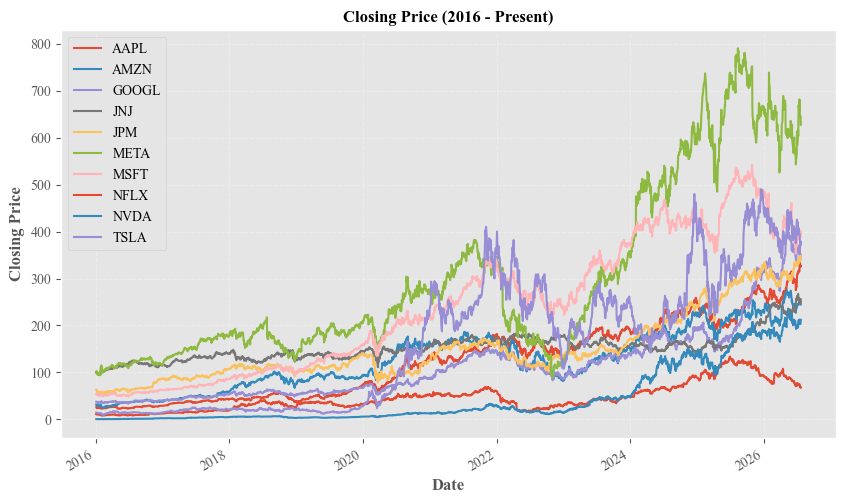

In [29]:
fig, ax = plt.subplots(figsize = (10, 6))
close.plot(ax = ax)
ax.set_title('Closing Price (2016 - Present)', fontweight = 'bold', fontsize = 12)
ax.set_xlabel('Date', fontweight = 'bold')
ax.set_ylabel('Closing Price', fontweight = 'bold')
ax.grid(True, linestyle = '--', alpha = 0.3)

plt.show()

In [30]:
close.AAPL

Date
2016-01-04     26.337500
2016-01-05     25.677500
2016-01-06     25.174999
2016-01-07     24.112499
2016-01-08     24.240000
                 ...    
2026-07-16    333.260010
2026-07-17    333.739990
2026-07-20    326.589996
2026-07-21    327.739990
2026-07-22    325.890015
Name: AAPL, Length: 2652, dtype: float64

In [31]:
close.AAPL.div(close.iloc[0, 0])

Date
2016-01-04     1.000000
2016-01-05     0.974941
2016-01-06     0.955861
2016-01-07     0.915520
2016-01-08     0.920361
                ...    
2026-07-16    12.653441
2026-07-17    12.671666
2026-07-20    12.400190
2026-07-21    12.443854
2026-07-22    12.373613
Name: AAPL, Length: 2652, dtype: float64

In [32]:
close.AAPL.div(close.iloc[0, 0]).mul(100)

Date
2016-01-04     100.000000
2016-01-05      97.494068
2016-01-06      95.586140
2016-01-07      91.551968
2016-01-08      92.036071
                 ...     
2026-07-16    1265.344147
2026-07-17    1267.166569
2026-07-20    1240.018988
2026-07-21    1244.385363
2026-07-22    1237.361251
Name: AAPL, Length: 2652, dtype: float64

In [33]:
close.iloc[0]

AAPL      26.337500
AMZN      31.849501
GOOGL     37.972000
JNJ      100.480003
JPM       63.619999
META     102.220001
MSFT      54.799999
NFLX      10.996000
NVDA       0.809250
TSLA      14.894000
Name: 2016-01-04 00:00:00, dtype: float64

In [34]:
close.div(close.iloc[0]).mul(100)

,AAPL,AMZN,GOOGL,JNJ,JPM,META,MSFT,NFLX,NVDA,TSLA
Date,,,,,,,,,,
2016-01-04,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
2016-01-05,97.494068,99.497638,100.275202,100.417992,100.172903,100.498926,100.456204,97.908326,101.606427,100.008952
2016-01-06,95.586140,99.318668,99.985514,99.910426,98.726819,100.733712,98.631387,107.020729,97.405009,98.043956
2016-01-07,91.551968,95.439485,97.571893,98.746017,94.734363,95.793384,95.200728,104.183340,93.543408,96.526568
2016-01-08,92.036071,95.299770,96.243289,97.691083,92.612385,95.216201,95.492705,101.300470,91.535374,94.445190
...,...,...,...,...,...,...,...,...,...,...
2026-07-16,1265.344147,784.596286,933.477274,248.775869,539.374410,650.107582,731.934328,676.154934,25628.667857,2625.621030
2026-07-17,1267.166569,776.244496,913.225503,251.831195,536.152172,631.980045,718.649658,627.046154,25061.476463,2557.002786
2026-07-20,1240.018988,784.910282,926.972477,247.631368,532.646968,631.823486,734.105865,614.768977,25119.555082,2481.334806


In [35]:
normalised_close = close.div(close.iloc[0]).mul(100)
normalised_close

,AAPL,AMZN,GOOGL,JNJ,JPM,META,MSFT,NFLX,NVDA,TSLA
Date,,,,,,,,,,
2016-01-04,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
2016-01-05,97.494068,99.497638,100.275202,100.417992,100.172903,100.498926,100.456204,97.908326,101.606427,100.008952
2016-01-06,95.586140,99.318668,99.985514,99.910426,98.726819,100.733712,98.631387,107.020729,97.405009,98.043956
2016-01-07,91.551968,95.439485,97.571893,98.746017,94.734363,95.793384,95.200728,104.183340,93.543408,96.526568
2016-01-08,92.036071,95.299770,96.243289,97.691083,92.612385,95.216201,95.492705,101.300470,91.535374,94.445190
...,...,...,...,...,...,...,...,...,...,...
2026-07-16,1265.344147,784.596286,933.477274,248.775869,539.374410,650.107582,731.934328,676.154934,25628.667857,2625.621030
2026-07-17,1267.166569,776.244496,913.225503,251.831195,536.152172,631.980045,718.649658,627.046154,25061.476463,2557.002786
2026-07-20,1240.018988,784.910282,926.972477,247.631368,532.646968,631.823486,734.105865,614.768977,25119.555082,2481.334806


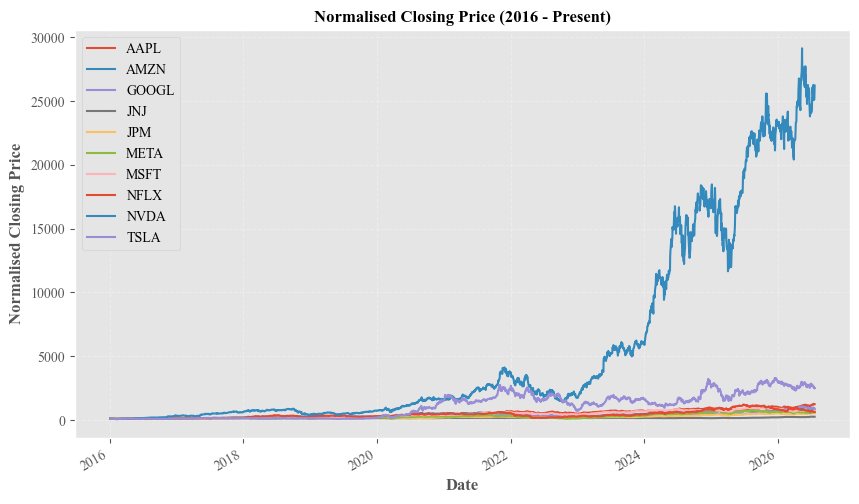

In [36]:
fig, ax = plt.subplots(figsize = (10, 6))
normalised_close.plot(ax = ax)
ax.set_title('Normalised Closing Price (2016 - Present)', fontweight = 'bold', fontsize = 12)
ax.set_xlabel('Date', fontweight = 'bold')
ax.set_ylabel('Normalised Closing Price', fontweight = 'bold')
ax.grid(True, linestyle = '--', alpha = 0.3)

plt.show()

In [37]:
aapl = close.AAPL.copy().to_frame()
aapl

,AAPL
Date,
2016-01-04,26.337500
2016-01-05,25.677500
2016-01-06,25.174999
2016-01-07,24.112499
2016-01-08,24.240000
...,...
2026-07-16,333.260010
2026-07-17,333.739990
2026-07-20,326.589996


In [38]:
aapl.shift(periods = 1)

,AAPL
Date,
2016-01-04,NaN
2016-01-05,26.337500
2016-01-06,25.677500
2016-01-07,25.174999
2016-01-08,24.112499
...,...
2026-07-16,327.500000
2026-07-17,333.260010
2026-07-20,333.739990


In [39]:
aapl['lag1'] = aapl.shift(periods = 1)
aapl

,AAPL,lag1
Date,,
2016-01-04,26.337500,NaN
2016-01-05,25.677500,26.337500
2016-01-06,25.174999,25.677500
2016-01-07,24.112499,25.174999
2016-01-08,24.240000,24.112499
...,...,...
2026-07-16,333.260010,327.500000
2026-07-17,333.739990,333.260010
2026-07-20,326.589996,333.739990


In [40]:
aapl['difference'] = aapl['AAPL'].sub(aapl['lag1'])
aapl

,AAPL,lag1,difference
Date,,,
2016-01-04,26.337500,NaN,NaN
2016-01-05,25.677500,26.337500,-0.660000
2016-01-06,25.174999,25.677500,-0.502501
2016-01-07,24.112499,25.174999,-1.062500
2016-01-08,24.240000,24.112499,0.127501
...,...,...,...
2026-07-16,333.260010,327.500000,5.760010
2026-07-17,333.739990,333.260010,0.479980
2026-07-20,326.589996,333.739990,-7.149994


In [41]:
aapl['percentage_change'] = aapl['AAPL'].div(aapl['lag1']).sub(1).mul(100)
aapl

,AAPL,lag1,difference,percentage_change
Date,,,,
2016-01-04,26.337500,NaN,NaN,NaN
2016-01-05,25.677500,26.337500,-0.660000,-2.505932
2016-01-06,25.174999,25.677500,-0.502501,-1.956968
2016-01-07,24.112499,25.174999,-1.062500,-4.220457
2016-01-08,24.240000,24.112499,0.127501,0.528774
...,...,...,...,...
2026-07-16,333.260010,327.500000,5.760010,1.758782
2026-07-17,333.739990,333.260010,0.479980,0.144026
2026-07-20,326.589996,333.739990,-7.149994,-2.142385


In [42]:
aapl['difference2'] = aapl['AAPL'].diff(periods = 1)
aapl

,AAPL,lag1,difference,percentage_change,difference2
Date,,,,,
2016-01-04,26.337500,NaN,NaN,NaN,NaN
2016-01-05,25.677500,26.337500,-0.660000,-2.505932,-0.660000
2016-01-06,25.174999,25.677500,-0.502501,-1.956968,-0.502501
2016-01-07,24.112499,25.174999,-1.062500,-4.220457,-1.062500
2016-01-08,24.240000,24.112499,0.127501,0.528774,0.127501
...,...,...,...,...,...
2026-07-16,333.260010,327.500000,5.760010,1.758782,5.760010
2026-07-17,333.739990,333.260010,0.479980,0.144026,0.479980
2026-07-20,326.589996,333.739990,-7.149994,-2.142385,-7.149994


In [43]:
aapl['percentage_change_2'] = aapl['AAPL'].pct_change(periods = 1).mul(100)
aapl

,AAPL,lag1,difference,percentage_change,difference2,percentage_change_2
Date,,,,,,
2016-01-04,26.337500,NaN,NaN,NaN,NaN,NaN
2016-01-05,25.677500,26.337500,-0.660000,-2.505932,-0.660000,-2.505932
2016-01-06,25.174999,25.677500,-0.502501,-1.956968,-0.502501,-1.956968
2016-01-07,24.112499,25.174999,-1.062500,-4.220457,-1.062500,-4.220457
2016-01-08,24.240000,24.112499,0.127501,0.528774,0.127501,0.528774
...,...,...,...,...,...,...
2026-07-16,333.260010,327.500000,5.760010,1.758782,5.760010,1.758782
2026-07-17,333.739990,333.260010,0.479980,0.144026,0.479980,0.144026
2026-07-20,326.589996,333.739990,-7.149994,-2.142385,-7.149994,-2.142385


In [44]:
del aapl['difference']
del aapl['difference2']
del aapl['percentage_change']
del aapl['lag1']
aapl

,AAPL,percentage_change_2
Date,,
2016-01-04,26.337500,NaN
2016-01-05,25.677500,-2.505932
2016-01-06,25.174999,-1.956968
2016-01-07,24.112499,-4.220457
2016-01-08,24.240000,0.528774
...,...,...
2026-07-16,333.260010,1.758782
2026-07-17,333.739990,0.144026
2026-07-20,326.589996,-2.142385


In [46]:
aapl.rename(columns = {'percentage_change_2': 'change'}, inplace = True)
aapl

,AAPL,change
Date,,
2016-01-04,26.337500,NaN
2016-01-05,25.677500,-2.505932
2016-01-06,25.174999,-1.956968
2016-01-07,24.112499,-4.220457
2016-01-08,24.240000,0.528774
...,...,...
2026-07-16,333.260010,1.758782
2026-07-17,333.739990,0.144026
2026-07-20,326.589996,-2.142385


In [49]:
print(aapl.index)

DatetimeIndex(['2016-01-04', '2016-01-05', '2016-01-06', '2016-01-07',
               '2016-01-08', '2016-01-11', '2016-01-12', '2016-01-13',
               '2016-01-14', '2016-01-15',
               ...
               '2026-07-09', '2026-07-10', '2026-07-13', '2026-07-14',
               '2026-07-15', '2026-07-16', '2026-07-17', '2026-07-20',
               '2026-07-21', '2026-07-22'],
              dtype='datetime64[ns]', name='Date', length=2652, freq=None)


In [51]:
aapl_monthly = aapl['AAPL'].resample('ME').last()
aapl_monthly

Date
2016-01-31     24.334999
2016-02-29     24.172501
2016-03-31     27.247499
2016-04-30     23.434999
2016-05-31     24.965000
                 ...    
2026-03-31    253.789993
2026-04-30    271.350006
2026-05-31    312.059998
2026-06-30    289.359985
2026-07-31    325.890015
Freq: ME, Name: AAPL, Length: 127, dtype: float64

In [52]:
aapl_bzmonthly = aapl['AAPL'].resample('BME').last()
aapl_bzmonthly

Date
2016-01-29     24.334999
2016-02-29     24.172501
2016-03-31     27.247499
2016-04-29     23.434999
2016-05-31     24.965000
                 ...    
2026-03-31    253.789993
2026-04-30    271.350006
2026-05-29    312.059998
2026-06-30    289.359985
2026-07-31    325.890015
Freq: BME, Name: AAPL, Length: 127, dtype: float64

In [53]:
aapl['AAPL'].resample('BME').last().pct_change(periods = 1).mul(100)

Date
2016-01-29          NaN
2016-02-29    -0.667756
2016-03-31    12.721062
2016-04-29   -13.992110
2016-05-31     6.528699
                ...    
2026-03-31    -3.932924
2026-04-30     6.919112
2026-05-29    15.002760
2026-06-30    -7.274246
2026-07-31    12.624423
Freq: BME, Name: AAPL, Length: 127, dtype: float64

In [54]:
aapl

,AAPL,change
Date,,
2016-01-04,26.337500,NaN
2016-01-05,25.677500,-2.505932
2016-01-06,25.174999,-1.956968
2016-01-07,24.112499,-4.220457
2016-01-08,24.240000,0.528774
...,...,...
2026-07-16,333.260010,1.758782
2026-07-17,333.739990,0.144026
2026-07-20,326.589996,-2.142385


In [58]:
del aapl['change']
aapl

,AAPL
Date,
2016-01-04,26.337500
2016-01-05,25.677500
2016-01-06,25.174999
2016-01-07,24.112499
2016-01-08,24.240000
...,...
2026-07-16,333.260010
2026-07-17,333.739990
2026-07-20,326.589996


In [59]:
returns = aapl.pct_change().dropna()
returns

,AAPL
Date,
2016-01-05,-0.025059
2016-01-06,-0.019570
2016-01-07,-0.042205
2016-01-08,0.005288
2016-01-11,0.016192
...,...
2026-07-16,0.017588
2026-07-17,0.001440
2026-07-20,-0.021424


In [60]:
returns.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2651 entries, 2016-01-05 to 2026-07-22
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AAPL    2651 non-null   float64
dtypes: float64(1)
memory usage: 41.4 KB


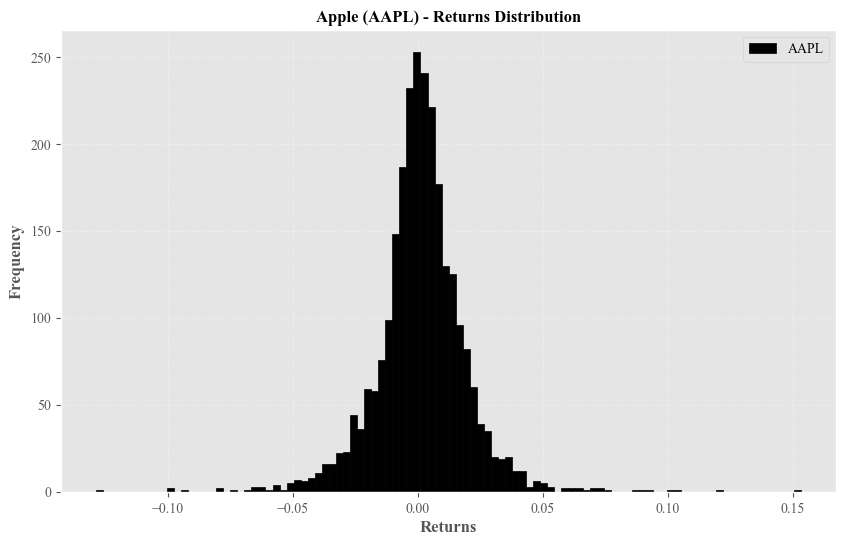

In [64]:
fig, ax = plt.subplots(figsize = (10, 6))
returns.plot(kind = 'hist', bins = 100, color = 'black', edgecolor = 'black', ax = ax)
ax.set_title('Apple (AAPL) - Returns Distribution', fontweight = 'bold', fontsize = 12)
ax.set_xlabel('Returns', fontweight = 'bold')
ax.set_ylabel('Frequency', fontweight = 'bold')
ax.grid(True, linestyle = '--', alpha = 0.3)

plt.show()

In [65]:
daily_mean_returns = returns.mean()
daily_mean_returns

AAPL    0.001115
dtype: float64

In [66]:
daily_returns_variance = returns.var()
daily_returns_variance

AAPL    0.000332
dtype: float64

In [67]:
daily_returns_sd = np.sqrt(daily_returns_variance)
daily_returns_sd

AAPL    0.018222
dtype: float64

In [68]:
daily_returns_sd = returns.std()
daily_returns_sd

AAPL    0.018222
dtype: float64

In [69]:
annual_mean_returns = daily_mean_returns * 252
annual_mean_returns

AAPL    0.281007
dtype: float64

In [70]:
annual_returns_variance = daily_returns_variance * 252
annual_returns_variance

AAPL    0.083671
dtype: float64

In [71]:
annual_returns_sd = np.sqrt(annual_returns_variance)
annual_returns_sd

AAPL    0.28926
dtype: float64

In [74]:
annual_returns_sd = returns.std() * np.sqrt(252)
annual_returns_sd

AAPL    0.28926
dtype: float64

In [75]:
tickers = ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'TSLA', 'META', 'NFLX', 'NVDA', 'JPM', 'JNJ']
start_date = '2016-01-01'
end_date = datetime.today().strftime('%Y-%m-%d')
stocks = yf.download(tickers, start = start_date, end = end_date, auto_adjust = False)
stocks

[*********************100%***********************]  10 of 10 completed


Price        Adj Close                                                  \
Ticker            AAPL        AMZN       GOOGL         JNJ         JPM   
Date                                                                     
2016-01-04   23.709105   31.849501   37.638252   75.337547   48.184082   
2016-01-05   23.114965   31.689501   37.741833   75.652451   48.267376   
2016-01-06   22.662617   31.632500   37.632805   75.270088   47.570591   
2016-01-07   21.706152   30.396999   36.724354   74.392815   45.646870   
2016-01-08   21.820929   30.352501   36.224297   73.598076   44.624413   
...                ...         ...         ...         ...         ...   
2026-07-16  333.260010  249.889999  354.459991  249.970001  343.149994   
2026-07-17  333.739990  247.229996  346.769989  253.039993  341.100006   
2026-07-20  326.589996  249.990005  351.989990  248.820007  338.869995   
2026-07-21  327.739990  247.550003  347.149994  250.610001  345.230011   
2026-07-22  325.890015  244.850006  342.089996  255.630005  348.209991   

Price                                                                  \
Ticker            META        MSFT       NFLX        NVDA        TSLA   
Date                                                                    
2016-01-04  101.330154   47.770725  10.996000    0.788626   14.894000   
2016-01-05  101.835732   47.988647  10.766000    0.801295   14.895333   
2016-01-06  102.073631   47.116920  11.768000    0.768161   14.602667   
2016-01-07   97.067596   45.478073  11.456000    0.737708   14.376667   
2016-01-08   96.482727   45.617546  11.139000    0.721872   14.066667   
...                ...         ...        ...         ...         ...   
2026-07-16  664.539978  401.100006  74.349998  207.399994  391.059998   
2026-07-17  646.010010  393.820007  68.949997  202.809998  380.839996   
2026-07-20  645.849976  402.290009  67.599998  203.279999  369.570007   
2026-07-21  643.809998  397.750000  68.669998  207.289993  378.929993   
2026-07-22  627.169983  390.339996  68.529999  212.059998  374.010010   

Price            Close                                                  \
Ticker            AAPL        AMZN       GOOGL         JNJ         JPM   
Date                                                                     
2016-01-04   26.337500   31.849501   37.972000  100.480003   63.619999   
2016-01-05   25.677500   31.689501   38.076500  100.900002   63.730000   
2016-01-06   25.174999   31.632500   37.966499  100.389999   62.810001   
2016-01-07   24.112499   30.396999   37.049999   99.220001   60.270000   
2016-01-08   24.240000   30.352501   36.545502   98.160004   58.919998   
...                ...         ...         ...         ...         ...   
2026-07-16  333.260010  249.889999  354.459991  249.970001  343.149994   
2026-07-17  333.739990  247.229996  346.769989  253.039993  341.100006   
2026-07-20  326.589996  249.990005  351.989990  248.820007  338.869995   
2026-07-21  327.739990  247.550003  347.149994  250.610001  345.230011   
2026-07-22  325.890015  244.850006  342.089996  255.630005  348.209991   

Price                                                                  \
Ticker            META        MSFT       NFLX        NVDA        TSLA   
Date                                                                    
2016-01-04  102.220001   54.799999  10.996000    0.809250   14.894000   
2016-01-05  102.730003   55.049999  10.766000    0.822250   14.895333   
2016-01-06  102.970001   54.049999  11.768000    0.788250   14.602667   
2016-01-07   97.919998   52.169998  11.456000    0.757000   14.376667   
2016-01-08   97.330002   52.330002  11.139000    0.740750   14.066667   
...                ...         ...        ...         ...         ...   
2026-07-16  664.539978  401.100006  74.349998  207.399994  391.059998   
2026-07-17  646.010010  393.820007  68.949997  202.809998  380.839996   
2026-07-20  645.849976  402.290009  67.599998  203.279999  369.570007   
2026-07-21  643.809998  397

In [76]:
close = stocks.loc[:, 'Close'].copy()
normalised_close = close.div(close.iloc[0]).mul(100)

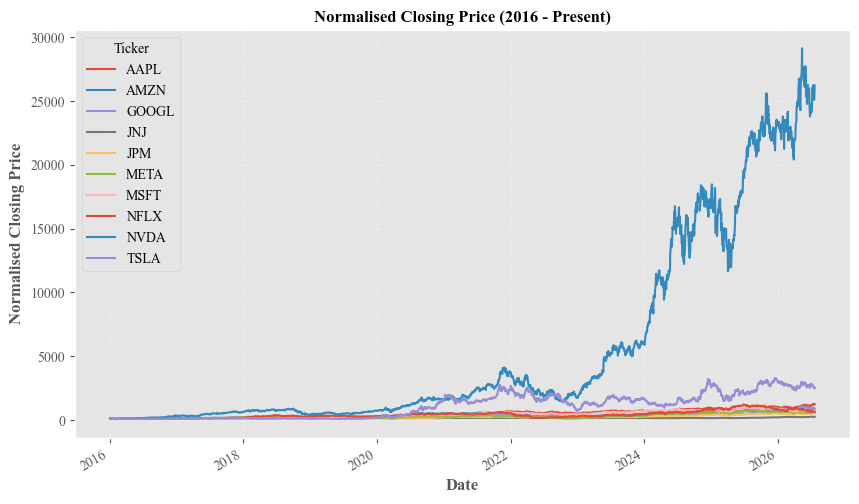

In [77]:
fig, ax = plt.subplots(figsize = (10, 6))
normalised_close.plot(ax = ax)
ax.set_title('Normalised Closing Price (2016 - Present)', fontweight = 'bold', fontsize = 12)
ax.set_xlabel('Date', fontweight = 'bold')
ax.set_ylabel('Normalised Closing Price', fontweight = 'bold')
ax.grid(True, linestyle = '--', alpha = 0.3)

plt.show()

In [78]:
returns = close.pct_change().dropna()
returns.head()

Ticker,AAPL,AMZN,GOOGL,JNJ,JPM,META,MSFT,NFLX,NVDA,TSLA
Date,,,,,,,,,,
2016-01-05,-0.025059,-0.005024,0.002752,0.004180,0.001729,0.004989,0.004562,-0.020917,0.016064,0.000090
2016-01-06,-0.019570,-0.001799,-0.002889,-0.005055,-0.014436,0.002336,-0.018165,0.093071,-0.041350,-0.019648
2016-01-07,-0.042205,-0.039058,-0.024140,-0.011655,-0.040439,-0.049043,-0.034783,-0.026513,-0.039645,-0.015477
2016-01-08,0.005288,-0.001464,-0.013617,-0.010683,-0.022399,-0.006025,0.003067,-0.027671,-0.021466,-0.021563
2016-01-11,0.016192,0.017610,0.002955,-0.006011,-0.001527,0.001849,-0.000573,0.032139,0.001687,-0.014929


In [79]:
returns.describe().T

,count,mean,std,min,25%,50%,75%,max
Ticker,,,,,,,,
AAPL,2651.0,0.001115,0.018222,-0.128647,-0.007189,0.001009,0.010016,0.153289
AMZN,2651.0,0.000981,0.020593,-0.140494,-0.008935,0.001168,0.011611,0.135359
GOOGL,2651.0,0.000996,0.018250,-0.116341,-0.007750,0.001203,0.010229,0.102244
JNJ,2651.0,0.000420,0.011668,-0.100379,-0.005018,0.000379,0.005999,0.079977
JPM,2651.0,0.000791,0.017289,-0.149649,-0.007090,0.000690,0.008930,0.180125
META,2651.0,0.000985,0.024404,-0.263901,-0.009561,0.000966,0.012331,0.232824
MSFT,2651.0,0.000887,0.017109,-0.147390,-0.007057,0.000913,0.009768,0.142169
NFLX,2651.0,0.001043,0.026317,-0.351166,-0.011288,0.000448,0.013517,0.190281
NVDA,2651.0,0.002582,0.031085,-0.187559,-0.013190,0.002677,0.018473,0.298067


In [80]:
returns.describe().T.loc[:, ['mean', 'std']]

,mean,std
Ticker,,
AAPL,0.001115,0.018222
AMZN,0.000981,0.020593
GOOGL,0.000996,0.018250
JNJ,0.000420,0.011668
JPM,0.000791,0.017289
META,0.000985,0.024404
MSFT,0.000887,0.017109
NFLX,0.001043,0.026317
NVDA,0.002582,0.031085


In [81]:
summary = returns.describe().T.loc[:, ['mean', 'std']]
summary

,mean,std
Ticker,,
AAPL,0.001115,0.018222
AMZN,0.000981,0.020593
GOOGL,0.000996,0.018250
JNJ,0.000420,0.011668
JPM,0.000791,0.017289
META,0.000985,0.024404
MSFT,0.000887,0.017109
NFLX,0.001043,0.026317
NVDA,0.002582,0.031085


In [82]:
summary['std'] = summary['std'] * np.sqrt(252)
summary['mean'] = summary['mean'] * 252
summary

,mean,std
Ticker,,
AAPL,0.281007,0.289260
AMZN,0.247268,0.326909
GOOGL,0.250984,0.289717
JNJ,0.105957,0.185229
JPM,0.199209,0.274452
META,0.248198,0.387403
MSFT,0.223579,0.271590
NFLX,0.262926,0.417765
NVDA,0.650562,0.493456


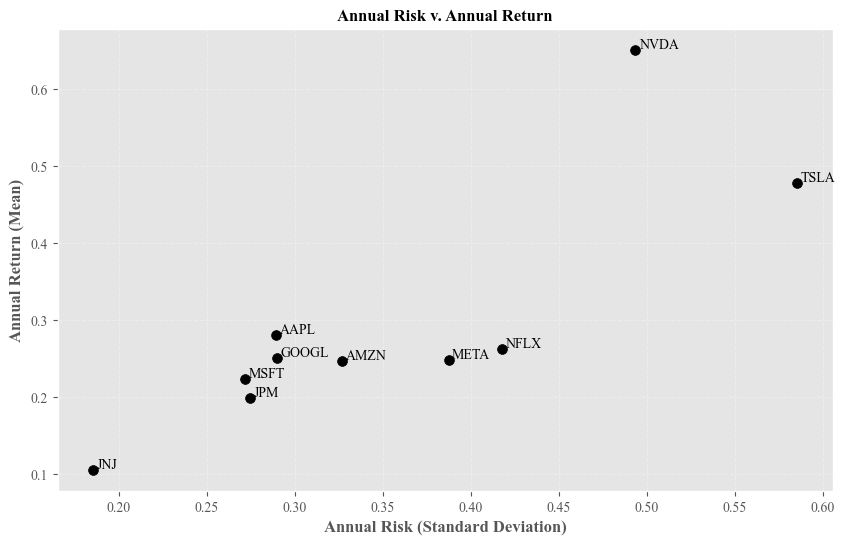

In [90]:
fig, ax = plt.subplots(figsize = (10, 6))
summary.plot.scatter(x = 'std', y = 'mean', s = 50, color = 'black', ax = ax)
for i in summary.index:
    ax.annotate(i, xy = (summary.loc[i, 'std'] + 0.002, summary.loc[i, 'mean'] + 0.002), fontsize = 10)
ax.set_title('Annual Risk v. Annual Return', fontweight = 'bold', fontsize = 12)
ax.set_xlabel('Annual Risk (Standard Deviation)', fontweight = 'bold')
ax.set_ylabel('Annual Return (Mean)', fontweight = 'bold')
ax.grid(True, linestyle = '--', alpha = 0.3)

plt.show()

In [91]:
returns

Ticker,AAPL,AMZN,GOOGL,JNJ,JPM,META,MSFT,NFLX,NVDA,TSLA
Date,,,,,,,,,,
2016-01-05,-0.025059,-0.005024,0.002752,0.004180,0.001729,0.004989,0.004562,-0.020917,0.016064,0.000090
2016-01-06,-0.019570,-0.001799,-0.002889,-0.005055,-0.014436,0.002336,-0.018165,0.093071,-0.041350,-0.019648
2016-01-07,-0.042205,-0.039058,-0.024140,-0.011655,-0.040439,-0.049043,-0.034783,-0.026513,-0.039645,-0.015477
2016-01-08,0.005288,-0.001464,-0.013617,-0.010683,-0.022399,-0.006025,0.003067,-0.027671,-0.021466,-0.021563
2016-01-11,0.016192,0.017610,0.002955,-0.006011,-0.001527,0.001849,-0.000573,0.032139,0.001687,-0.014929
...,...,...,...,...,...,...,...,...,...,...
2026-07-16,0.017588,-0.019886,-0.044376,0.011942,-0.010839,-0.024614,0.013826,0.009093,-0.024000,-0.008619
2026-07-17,0.001440,-0.010645,-0.021695,0.012281,-0.005974,-0.027884,-0.018150,-0.072629,-0.022131,-0.026134
2026-07-20,-0.021424,0.011164,0.015053,-0.016677,-0.006538,-0.000248,0.021507,-0.019579,0.002317,-0.029592


In [92]:
returns.cov()

Ticker,AAPL,AMZN,GOOGL,JNJ,JPM,META,MSFT,NFLX,NVDA,TSLA
Ticker,,,,,,,,,,
AAPL,0.000332,0.000211,0.000196,0.000061,0.000128,0.000225,0.000202,0.000199,0.000296,0.000290
AMZN,0.000211,0.000424,0.000238,0.000034,0.000107,0.000304,0.000228,0.000278,0.000338,0.000309
GOOGL,0.000196,0.000238,0.000333,0.000051,0.000124,0.000266,0.000207,0.000205,0.000300,0.000261
JNJ,0.000061,0.000034,0.000051,0.000136,0.000066,0.000039,0.000056,0.000037,0.000036,0.000027
JPM,0.000128,0.000107,0.000124,0.000066,0.000299,0.000132,0.000121,0.000100,0.000177,0.000173
META,0.000225,0.000304,0.000266,0.000039,0.000132,0.000596,0.000240,0.000282,0.000369,0.000302
MSFT,0.000202,0.000228,0.000207,0.000056,0.000121,0.000240,0.000293,0.000212,0.000317,0.000253
NFLX,0.000199,0.000278,0.000205,0.000037,0.000100,0.000282,0.000212,0.000693,0.000342,0.000314
NVDA,0.000296,0.000338,0.000300,0.000036,0.000177,0.000369,0.000317,0.000342,0.000966,0.000485


In [93]:
returns.corr()

Ticker,AAPL,AMZN,GOOGL,JNJ,JPM,META,MSFT,NFLX,NVDA,TSLA
Ticker,,,,,,,,,,
AAPL,1.000000,0.563023,0.588481,0.287475,0.407680,0.506680,0.648181,0.415052,0.522992,0.431837
AMZN,0.563023,1.000000,0.632955,0.143496,0.299548,0.603952,0.647022,0.513848,0.527988,0.406446
GOOGL,0.588481,0.632955,1.000000,0.237934,0.391587,0.596378,0.662743,0.427417,0.528444,0.387283
JNJ,0.287475,0.143496,0.237934,1.000000,0.326361,0.136224,0.279155,0.121833,0.099713,0.062734
JPM,0.407680,0.299548,0.391587,0.326361,1.000000,0.313578,0.409618,0.219794,0.329109,0.271338
META,0.506680,0.603952,0.596378,0.136224,0.313578,1.000000,0.574535,0.439244,0.486346,0.335793
MSFT,0.648181,0.647022,0.662743,0.279155,0.409618,0.574535,1.000000,0.470155,0.596310,0.400295
NFLX,0.415052,0.513848,0.427417,0.121833,0.219794,0.439244,0.470155,1.000000,0.418405,0.323008
NVDA,0.522992,0.527988,0.528444,0.099713,0.329109,0.486346,0.596310,0.418405,1.000000,0.422851


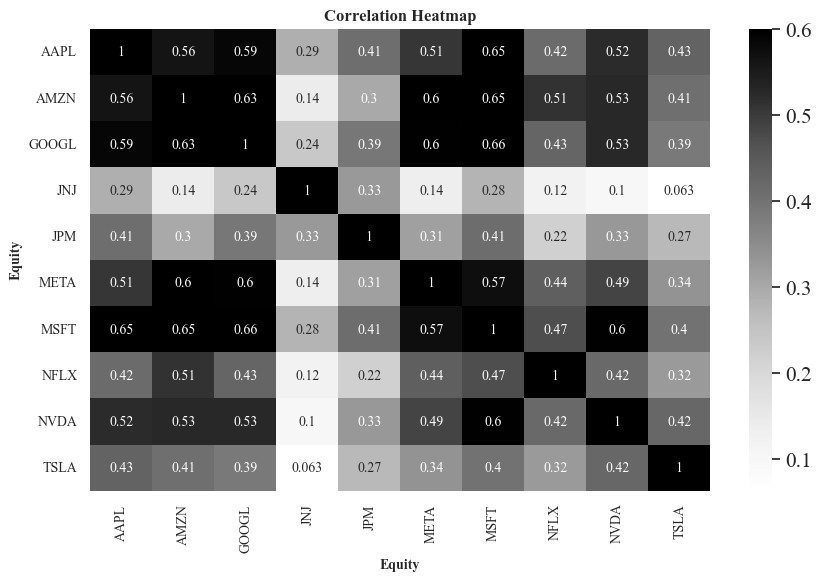

In [101]:
from matplotlib import rcParams
rcParams['font.family'] = 'Times New Roman'

fig, ax = plt.subplots(figsize = (10, 6))
sns.heatmap(returns.corr(), cmap = 'Greys', annot = True, annot_kws = {'size': 10}, vmax = 0.6, ax = ax)
ax.set_title('Correlation Heatmap', fontweight = 'bold', fontsize = 12)
ax.set_xlabel('Equity', fontweight = 'bold', fontsize = 10)
ax.set_ylabel('Equity', fontweight = 'bold', fontsize = 10)
ax.tick_params(axis = 'both', labelsize = 10)
ax.grid(False)

plt.show()

In [114]:
start_date = '2016-01-01'
end_date = datetime.today().strftime('%Y-%m-%d')
SPY = yf.download('SPY', start = start_date, end = end_date, auto_adjust = False)
spy = SPY['Close'].copy()
spy.columns = ['Close']
spy

[*********************100%***********************]  1 of 1 completed


,Close
Date,
2016-01-04,201.020004
2016-01-05,201.360001
2016-01-06,198.820007
2016-01-07,194.050003
2016-01-08,191.919998
...,...
2026-07-16,750.719971
2026-07-17,743.289978
2026-07-20,742.090027


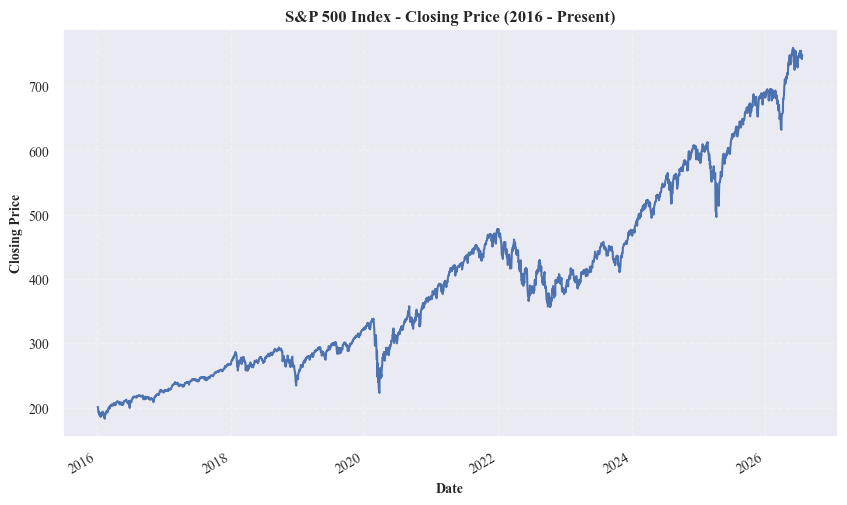

In [129]:
fig, ax = plt.subplots(figsize = (10, 6))
spy.plot(ax = ax, legend = False)
ax.set_title('S&P 500 Index - Closing Price (2016 - Present)', fontweight = 'bold', fontsize = 12)
ax.set_xlabel('Date', fontweight = 'bold', fontsize = 10)
ax.set_ylabel('Closing Price', fontweight = 'bold', fontsize = 10)
ax.tick_params(axis = 'both', labelsize = 10)
ax.grid(True, linestyle = '--', alpha = 0.3)

plt.show()

In [130]:
spy_rolling = spy.rolling(window = 10)
spy_rolling

Rolling [window=10,center=False,axis=0,method=single]

In [131]:
spy_rolling = spy_rolling.mean()
spy_rolling

,Close
Date,
2016-01-04,NaN
2016-01-05,NaN
2016-01-06,NaN
2016-01-07,NaN
2016-01-08,NaN
...,...
2026-07-16,750.236011
2026-07-17,750.087006
2026-07-20,749.168005


In [132]:
spy_rolling.head(15)

,Close
Date,
2016-01-04,NaN
2016-01-05,NaN
2016-01-06,NaN
2016-01-07,NaN
2016-01-08,NaN
2016-01-11,NaN
2016-01-12,NaN
2016-01-13,NaN
2016-01-14,NaN


In [128]:
spy.rolling(window = 10).median()

,Close
Date,
2016-01-04,NaN
2016-01-05,NaN
2016-01-06,NaN
2016-01-07,NaN
2016-01-08,NaN
...,...
2026-07-16,751.000000
2026-07-17,751.000000
2026-07-20,749.944977


In [133]:
spy.rolling(window = 10).max()

,Close
Date,
2016-01-04,NaN
2016-01-05,NaN
2016-01-06,NaN
2016-01-07,NaN
2016-01-08,NaN
...,...
2026-07-16,754.950012
2026-07-17,754.950012
2026-07-20,754.950012


In [135]:
spy.rolling(window = 10, min_periods = 5).max().head(15)

,Close
Date,
2016-01-04,NaN
2016-01-05,NaN
2016-01-06,NaN
2016-01-07,NaN
2016-01-08,201.360001
2016-01-11,201.360001
2016-01-12,201.360001
2016-01-13,201.360001
2016-01-14,201.360001


In [136]:
spy

,Close
Date,
2016-01-04,201.020004
2016-01-05,201.360001
2016-01-06,198.820007
2016-01-07,194.050003
2016-01-08,191.919998
...,...
2026-07-16,750.719971
2026-07-17,743.289978
2026-07-20,742.090027


In [137]:
spy['SMA50'] = spy.rolling(window = 50, min_periods = 50).mean()
spy.head(52)

,Close,SMA50
Date,,
2016-01-04,201.020004,NaN
2016-01-05,201.360001,NaN
2016-01-06,198.820007,NaN
2016-01-07,194.050003,NaN
2016-01-08,191.919998,NaN
2016-01-11,192.110001,NaN
2016-01-12,193.660004,NaN
2016-01-13,188.830002,NaN
2016-01-14,191.929993,NaN


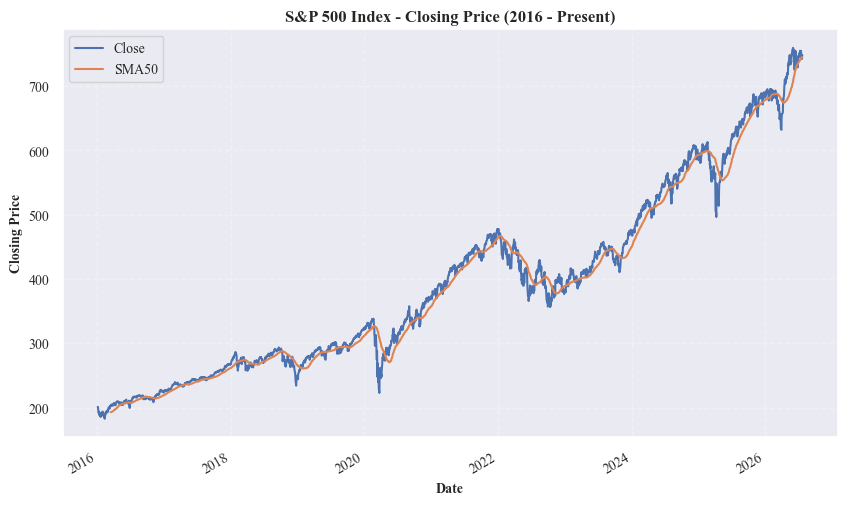

In [140]:
fig, ax = plt.subplots(figsize = (10, 6))
spy.plot(ax = ax)
ax.set_title('S&P 500 Index - Closing Price (2016 - Present)', fontweight = 'bold', fontsize = 12)
ax.set_xlabel('Date', fontweight = 'bold', fontsize = 10)
ax.set_ylabel('Closing Price', fontweight = 'bold', fontsize = 10)
ax.legend(loc = 'upper left', fontsize = 10)
ax.tick_params(axis = 'both', labelsize = 10)
ax.grid(True, linestyle = '--', alpha = 0.3)

plt.show()

In [141]:
spy['SMA200'] = spy['Close'].rolling(window = 200, min_periods = 200).mean()
spy.head(252)

,Close,SMA50,SMA200
Date,,,
2016-01-04,201.020004,NaN,NaN
2016-01-05,201.360001,NaN,NaN
2016-01-06,198.820007,NaN,NaN
2016-01-07,194.050003,NaN,NaN
2016-01-08,191.919998,NaN,NaN
...,...,...,...
2016-12-23,225.710007,218.6232,213.14965
2016-12-27,226.270004,218.8862,213.26850
2016-12-28,224.399994,219.1266,213.37965


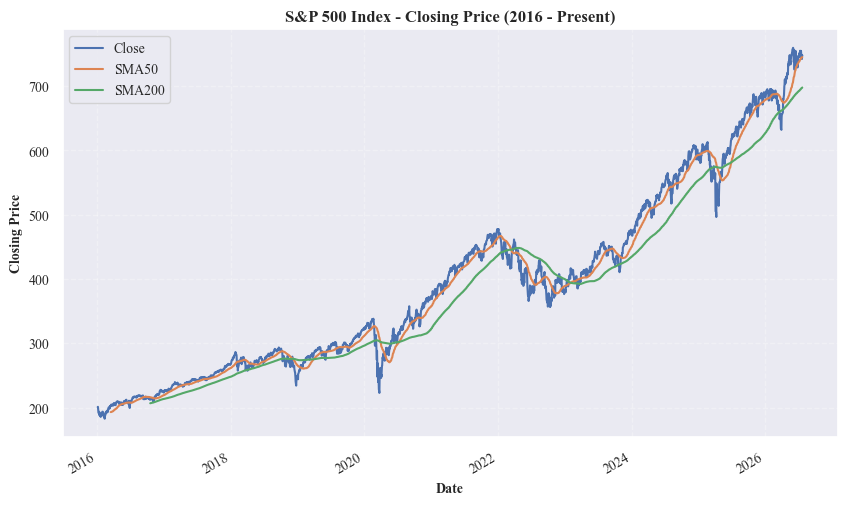

In [142]:
fig, ax = plt.subplots(figsize = (10, 6))
spy.plot(ax = ax)
ax.set_title('S&P 500 Index - Closing Price (2016 - Present)', fontweight = 'bold', fontsize = 12)
ax.set_xlabel('Date', fontweight = 'bold', fontsize = 10)
ax.set_ylabel('Closing Price', fontweight = 'bold', fontsize = 10)
ax.legend(loc = 'upper left', fontsize = 10)
ax.tick_params(axis = 'both', labelsize = 10)
ax.grid(True, linestyle = '--', alpha = 0.3)

plt.show()

In [143]:
spy['EMA100'] = spy['Close'].ewm(span = 100, min_periods = 100).mean()
spy

,Close,SMA50,SMA200,EMA100
Date,,,,
2016-01-04,201.020004,NaN,NaN,NaN
2016-01-05,201.360001,NaN,NaN,NaN
2016-01-06,198.820007,NaN,NaN,NaN
2016-01-07,194.050003,NaN,NaN,NaN
2016-01-08,191.919998,NaN,NaN,NaN
...,...,...,...,...
2026-07-16,750.719971,743.990002,696.29355,721.528800
2026-07-17,743.289978,744.380402,696.69160,721.959714
2026-07-20,742.090027,744.545602,697.07115,722.358334


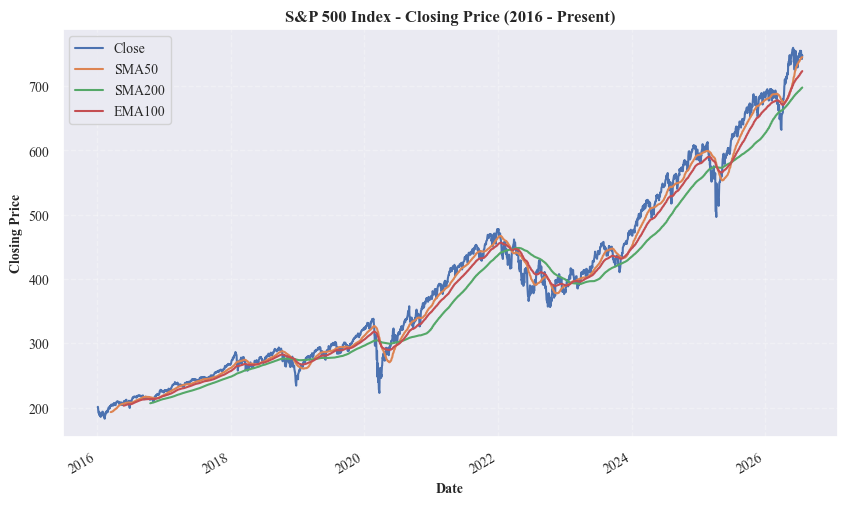

In [144]:
fig, ax = plt.subplots(figsize = (10, 6))
spy.plot(ax = ax)
ax.set_title('S&P 500 Index - Closing Price (2016 - Present)', fontweight = 'bold', fontsize = 12)
ax.set_xlabel('Date', fontweight = 'bold', fontsize = 10)
ax.set_ylabel('Closing Price', fontweight = 'bold', fontsize = 10)
ax.legend(loc = 'upper left', fontsize = 10)
ax.tick_params(axis = 'both', labelsize = 10)
ax.grid(True, linestyle = '--', alpha = 0.3)

plt.show()

In [145]:
spy['Day'] = spy.index.day_name()
spy

,Close,SMA50,SMA200,EMA100,Day
Date,,,,,
2016-01-04,201.020004,NaN,NaN,NaN,Monday
2016-01-05,201.360001,NaN,NaN,NaN,Tuesday
2016-01-06,198.820007,NaN,NaN,NaN,Wednesday
2016-01-07,194.050003,NaN,NaN,NaN,Thursday
2016-01-08,191.919998,NaN,NaN,NaN,Friday
...,...,...,...,...,...
2026-07-16,750.719971,743.990002,696.29355,721.528800,Thursday
2026-07-17,743.289978,744.380402,696.69160,721.959714,Friday
2026-07-20,742.090027,744.545602,697.07115,722.358334,Monday


In [146]:
spy['Quarter'] = spy.index.quarter
spy

,Close,SMA50,SMA200,EMA100,Day,Quarter
Date,,,,,,
2016-01-04,201.020004,NaN,NaN,NaN,Monday,1
2016-01-05,201.360001,NaN,NaN,NaN,Tuesday,1
2016-01-06,198.820007,NaN,NaN,NaN,Wednesday,1
2016-01-07,194.050003,NaN,NaN,NaN,Thursday,1
2016-01-08,191.919998,NaN,NaN,NaN,Friday,1
...,...,...,...,...,...,...
2026-07-16,750.719971,743.990002,696.29355,721.528800,Thursday,3
2026-07-17,743.289978,744.380402,696.69160,721.959714,Friday,3
2026-07-20,742.090027,744.545602,697.07115,722.358334,Monday,3


In [147]:
start_date = '2016-01-01'
end_date = datetime.today().strftime('%Y-%m-%d')
SPY = yf.download('SPY', start = start_date, end = end_date, auto_adjust = False)
spy = SPY['Close'].copy()
spy.columns = ['Close']
spy

[*********************100%***********************]  1 of 1 completed


,Close
Date,
2016-01-04,201.020004
2016-01-05,201.360001
2016-01-06,198.820007
2016-01-07,194.050003
2016-01-08,191.919998
...,...
2026-07-16,750.719971
2026-07-17,743.289978
2026-07-20,742.090027


In [148]:
all_days = pd.date_range(start = start_date , end = end_date, freq = 'D')
all_days

DatetimeIndex(['2016-01-01', '2016-01-02', '2016-01-03', '2016-01-04',
               '2016-01-05', '2016-01-06', '2016-01-07', '2016-01-08',
               '2016-01-09', '2016-01-10',
               ...
               '2026-07-14', '2026-07-15', '2026-07-16', '2026-07-17',
               '2026-07-18', '2026-07-19', '2026-07-20', '2026-07-21',
               '2026-07-22', '2026-07-23'],
              dtype='datetime64[ns]', length=3857, freq='D')

In [149]:
spy

,Close
Date,
2016-01-04,201.020004
2016-01-05,201.360001
2016-01-06,198.820007
2016-01-07,194.050003
2016-01-08,191.919998
...,...
2026-07-16,750.719971
2026-07-17,743.289978
2026-07-20,742.090027


In [150]:
spy = spy.reindex(all_days)
spy

,Close
2016-01-01,NaN
2016-01-02,NaN
2016-01-03,NaN
2016-01-04,201.020004
2016-01-05,201.360001
...,...
2026-07-19,NaN
2026-07-20,742.090027
2026-07-21,748.280029
2026-07-22,747.409973


In [152]:
spy.ffill()

,Close
2016-01-01,NaN
2016-01-02,NaN
2016-01-03,NaN
2016-01-04,201.020004
2016-01-05,201.360001
...,...
2026-07-19,743.289978
2026-07-20,742.090027
2026-07-21,748.280029
2026-07-22,747.409973


In [153]:
spy.bfill()

,Close
2016-01-01,201.020004
2016-01-02,201.020004
2016-01-03,201.020004
2016-01-04,201.020004
2016-01-05,201.360001
...,...
2026-07-19,742.090027
2026-07-20,742.090027
2026-07-21,748.280029
2026-07-22,747.409973


In [154]:
start_date = '2016-01-01'
end_date = datetime.today().strftime('%Y-%m-%d')
SPY = yf.download('SPY', start = start_date, end = end_date, auto_adjust = False, interval = '1wk')
spy = SPY['Close'].copy()
spy.columns = ['Close']
spy

[*********************100%***********************]  1 of 1 completed


,Close
Date,
2016-01-01,194.050003
2016-01-08,191.929993
2016-01-15,186.690002
2016-01-22,189.110001
2016-01-29,191.600006
...,...
2026-06-19,734.299988
2026-06-26,744.780029
2026-07-03,751.710022


In [159]:
aapl = yf.download('AAPL', auto_adjust = False, period = 'max')
aapl = aapl['Close'].copy()
aapl.columns = ['Close']
aapl

[*********************100%***********************]  1 of 1 completed


,Close
Date,
1980-12-12,0.128348
1980-12-15,0.121652
1980-12-16,0.112723
1980-12-17,0.115513
1980-12-18,0.118862
...,...
2026-07-17,333.739990
2026-07-20,326.589996
2026-07-21,327.739990


In [160]:
aapl['daily_returns'] = np.log(aapl.div(aapl.shift(1)))
aapl

,Close,daily_returns
Date,,
1980-12-12,0.128348,NaN
1980-12-15,0.121652,-0.053581
1980-12-16,0.112723,-0.076231
1980-12-17,0.115513,0.024450
1980-12-18,0.118862,0.028580
...,...,...
2026-07-17,333.739990,0.001439
2026-07-20,326.589996,-0.021657
2026-07-21,327.739990,0.003515


In [163]:
aapl.dropna(inplace = True)
aapl

,Close,daily_returns
Date,,
1980-12-15,0.121652,-0.053581
1980-12-16,0.112723,-0.076231
1980-12-17,0.115513,0.024450
1980-12-18,0.118862,0.028580
1980-12-19,0.126116,0.059239
...,...,...
2026-07-17,333.739990,0.001439
2026-07-20,326.589996,-0.021657
2026-07-21,327.739990,0.003515


In [165]:
print(aapl['daily_returns'].sum())

7.8222680280236325


In [166]:
print(np.exp(aapl['daily_returns'].sum()))

2495.5589921061664


In [167]:
aapl['cumulative_returns'] = aapl['daily_returns'].cumsum().apply(np.exp)
aapl

,Close,daily_returns,cumulative_returns
Date,,,
1980-12-15,0.121652,-0.053581,0.947829
1980-12-16,0.112723,-0.076231,0.878261
1980-12-17,0.115513,0.024450,0.899998
1980-12-18,0.118862,0.028580,0.926092
1980-12-19,0.126116,0.059239,0.982610
...,...,...,...
2026-07-17,333.739990,0.001439,2600.274322
2026-07-20,326.589996,-0.021657,2544.566448
2026-07-21,327.739990,0.003515,2553.526415


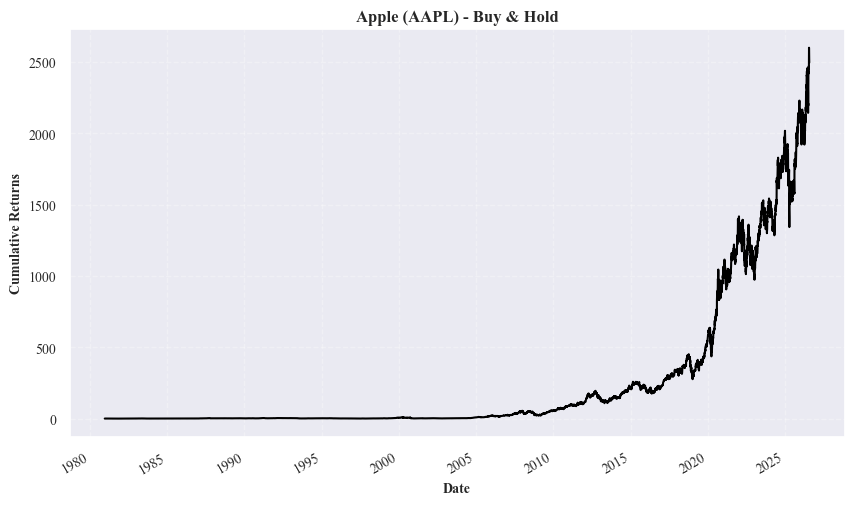

In [169]:
fig, ax = plt.subplots(figsize = (10, 6))
aapl['cumulative_returns'].plot(color = 'black', ax = ax)
ax.set_title('Apple (AAPL) - Buy & Hold', fontweight = 'bold', fontsize = 12)
ax.set_xlabel('Date', fontweight = 'bold', fontsize = 10)
ax.set_ylabel('Cumulative Returns', fontweight = 'bold', fontsize = 10)
ax.tick_params(axis = 'both', labelsize = 10)
ax.grid(True, linestyle = '--', alpha = 0.3)

plt.show()

In [171]:
print(aapl['daily_returns'].mean() * 252)

0.17151409928321198


In [172]:
print(aapl['daily_returns'].std() * np.sqrt(252))

0.4435601760527777


In [173]:
aapl['cumulative_maximum'] = aapl['cumulative_returns'].cummax()
aapl

,Close,daily_returns,cumulative_returns,cumulative_maximum
Date,,,,
1980-12-15,0.121652,-0.053581,0.947829,0.947829
1980-12-16,0.112723,-0.076231,0.878261,0.947829
1980-12-17,0.115513,0.024450,0.899998,0.947829
1980-12-18,0.118862,0.028580,0.926092,0.947829
1980-12-19,0.126116,0.059239,0.982610,0.982610
...,...,...,...,...
2026-07-17,333.739990,0.001439,2600.274322,2600.274322
2026-07-20,326.589996,-0.021657,2544.566448,2600.274322
2026-07-21,327.739990,0.003515,2553.526415,2600.274322


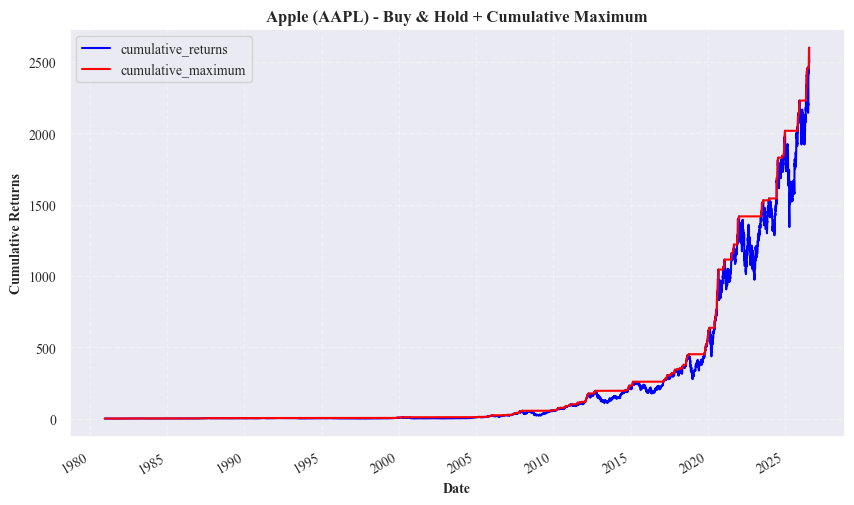

In [176]:
fig, ax = plt.subplots(figsize = (10, 6))
aapl[['cumulative_returns', 'cumulative_maximum']].plot(color = ['blue', 'red'], ax = ax)
ax.set_title('Apple (AAPL) - Buy & Hold + Cumulative Maximum', fontweight = 'bold', fontsize = 12)
ax.set_xlabel('Date', fontweight = 'bold', fontsize = 10)
ax.set_ylabel('Cumulative Returns', fontweight = 'bold', fontsize = 10)
ax.legend(loc = 'upper left', fontsize = 10)
ax.tick_params(axis = 'both', labelsize = 10)
ax.grid(True, linestyle = '--', alpha = 0.3)

plt.show()

In [177]:
aapl

,Close,daily_returns,cumulative_returns,cumulative_maximum
Date,,,,
1980-12-15,0.121652,-0.053581,0.947829,0.947829
1980-12-16,0.112723,-0.076231,0.878261,0.947829
1980-12-17,0.115513,0.024450,0.899998,0.947829
1980-12-18,0.118862,0.028580,0.926092,0.947829
1980-12-19,0.126116,0.059239,0.982610,0.982610
...,...,...,...,...
2026-07-17,333.739990,0.001439,2600.274322,2600.274322
2026-07-20,326.589996,-0.021657,2544.566448,2600.274322
2026-07-21,327.739990,0.003515,2553.526415,2600.274322


In [178]:
aapl['drawdown'] = aapl['cumulative_maximum'] - aapl['cumulative_returns']
aapl

,Close,daily_returns,cumulative_returns,cumulative_maximum,drawdown
Date,,,,,
1980-12-15,0.121652,-0.053581,0.947829,0.947829,0.000000
1980-12-16,0.112723,-0.076231,0.878261,0.947829,0.069569
1980-12-17,0.115513,0.024450,0.899998,0.947829,0.047831
1980-12-18,0.118862,0.028580,0.926092,0.947829,0.021738
1980-12-19,0.126116,0.059239,0.982610,0.982610,0.000000
...,...,...,...,...,...
2026-07-17,333.739990,0.001439,2600.274322,2600.274322,0.000000
2026-07-20,326.589996,-0.021657,2544.566448,2600.274322,55.707875
2026-07-21,327.739990,0.003515,2553.526415,2600.274322,46.747907


In [180]:
print(aapl['drawdown'].max())

674.7280490331036


In [181]:
print(aapl['drawdown'].idxmax())

2025-04-08 00:00:00


In [182]:
aapl.loc[(aapl.index == '2025-04-08')]

,Close,daily_returns,cumulative_returns,cumulative_maximum,drawdown
Date,,,,,
2025-04-08,172.419998,-0.051102,1343.378999,2018.107048,674.728049


In [183]:
aapl.loc[(aapl.index <= '2025-04-08')]

,Close,daily_returns,cumulative_returns,cumulative_maximum,drawdown
Date,,,,,
1980-12-15,0.121652,-0.053581,0.947829,0.947829,0.000000
1980-12-16,0.112723,-0.076231,0.878261,0.947829,0.069569
1980-12-17,0.115513,0.024450,0.899998,0.947829,0.047831
1980-12-18,0.118862,0.028580,0.926092,0.947829,0.021738
1980-12-19,0.126116,0.059239,0.982610,0.982610,0.000000
...,...,...,...,...,...
2025-04-02,223.889999,0.003131,1744.398135,2018.107048,273.708913
2025-04-03,203.190002,-0.097013,1583.117880,2018.107048,434.989167
2025-04-04,188.380005,-0.075680,1467.728483,2018.107048,550.378565


In [184]:
aapl['drawdown_percentage'] = (aapl['cumulative_maximum'] - aapl['cumulative_returns']) / aapl['cumulative_maximum']
aapl

,Close,daily_returns,cumulative_returns,cumulative_maximum,drawdown,drawdown_percentage
Date,,,,,,
1980-12-15,0.121652,-0.053581,0.947829,0.947829,0.000000,0.000000
1980-12-16,0.112723,-0.076231,0.878261,0.947829,0.069569,0.073398
1980-12-17,0.115513,0.024450,0.899998,0.947829,0.047831,0.050464
1980-12-18,0.118862,0.028580,0.926092,0.947829,0.021738,0.022934
1980-12-19,0.126116,0.059239,0.982610,0.982610,0.000000,0.000000
...,...,...,...,...,...,...
2026-07-17,333.739990,0.001439,2600.274322,2600.274322,0.000000,0.000000
2026-07-20,326.589996,-0.021657,2544.566448,2600.274322,55.707875,0.021424
2026-07-21,327.739990,0.003515,2553.526415,2600.274322,46.747907,0.017978


In [185]:
print(aapl['drawdown_percentage'].max())

0.82216567924191


In [187]:
print(aapl['drawdown_percentage'].idxmax())

1997-12-23 00:00:00


In [188]:
aapl.loc[(aapl.index == '1997-12-23')]

,Close,daily_returns,cumulative_returns,cumulative_maximum,drawdown,drawdown_percentage
Date,,,,,,
1997-12-23,0.115513,-0.02858,0.899998,5.060882,4.160883,0.822166


In [189]:
aapl.loc[(aapl.index <= '1997-12-23')]

,Close,daily_returns,cumulative_returns,cumulative_maximum,drawdown,drawdown_percentage
Date,,,,,,
1980-12-15,0.121652,-0.053581,0.947829,0.947829,0.000000,0.000000
1980-12-16,0.112723,-0.076231,0.878261,0.947829,0.069569,0.073398
1980-12-17,0.115513,0.024450,0.899998,0.947829,0.047831,0.050464
1980-12-18,0.118862,0.028580,0.926092,0.947829,0.021738,0.022934
1980-12-19,0.126116,0.059239,0.982610,0.982610,0.000000,0.000000
...,...,...,...,...,...,...
1997-12-17,0.124442,-0.026549,0.969567,5.060882,4.091315,0.808419
1997-12-18,0.123326,-0.009008,0.960872,5.060882,4.100010,0.810137
1997-12-19,0.122210,-0.009090,0.952177,5.060882,4.108705,0.811856


<style>
h1, h1 *, 
h2, h2 *, 
h3, h3 *, 
h4, h4 *, 
h5, h5 *, 
h6, h6 * {
  font-family: "Times New Roman", Times, serif !important;

</style>

#### **Simple Moving Average Strategy**

In [190]:
data = aapl['Close'].loc[(aapl.index >= '1991-01-01')]

In [191]:
data = data.to_frame()

In [192]:
data

,Close
Date,
1991-01-02,0.388393
1991-01-03,0.383929
1991-01-04,0.386161
1991-01-07,0.386161
1991-01-08,0.386161
...,...
2026-07-17,333.739990
2026-07-20,326.589996
2026-07-21,327.739990


In [194]:
sma_s = 50
sma_l = 100
data['sma_s'] = data['Close'].rolling(sma_s).mean()
data['sma_l'] = data['Close'].rolling(sma_l).mean()
data

,Close,sma_s,sma_l
Date,,,
1991-01-02,0.388393,NaN,NaN
1991-01-03,0.383929,NaN,NaN
1991-01-04,0.386161,NaN,NaN
1991-01-07,0.386161,NaN,NaN
1991-01-08,0.386161,NaN,NaN
...,...,...,...
2026-07-17,333.739990,302.6484,282.2360
2026-07-20,326.589996,303.4300,282.7805
2026-07-21,327.739990,304.2360,283.3156


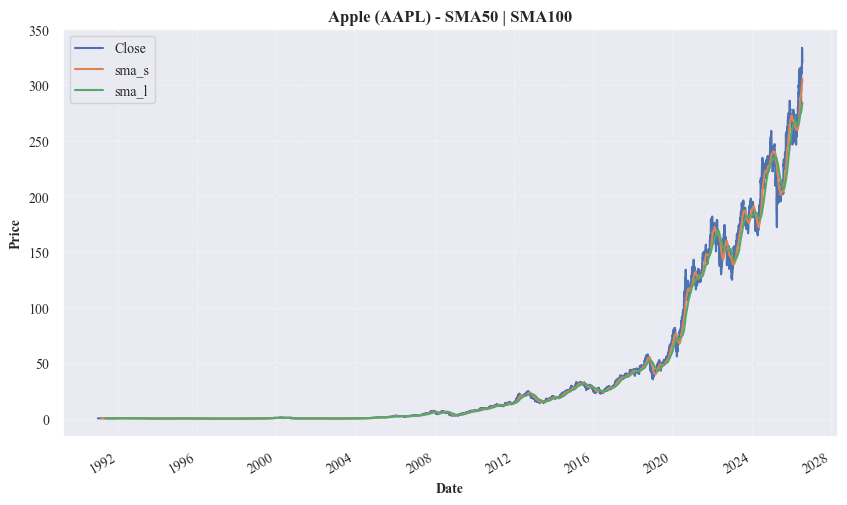

In [198]:
fig, ax = plt.subplots(figsize = (10, 6))
data.plot(ax = ax)
ax.set_title('Apple (AAPL) - SMA{} | SMA{}'.format(sma_s, sma_l), fontweight = 'bold', fontsize = 12)
ax.set_xlabel('Date', fontweight = 'bold', fontsize = 10)
ax.set_ylabel('Price', fontweight = 'bold', fontsize = 10)
ax.legend(fontsize = 10)
ax.tick_params(axis = 'both', labelsize = 10)
ax.grid(True, linestyle = '--', alpha = 0.3)

plt.show()

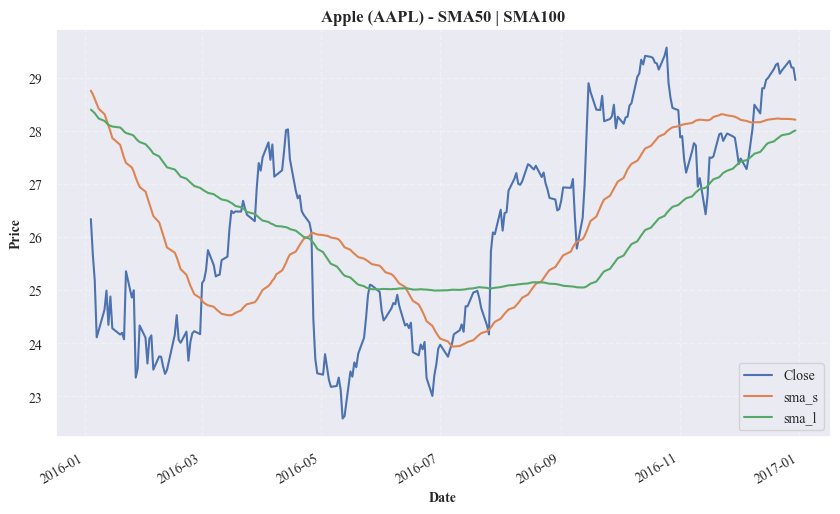

In [199]:
fig, ax = plt.subplots(figsize = (10, 6))
data.loc['2016'].plot(ax = ax)
ax.set_title('Apple (AAPL) - SMA{} | SMA{}'.format(sma_s, sma_l), fontweight = 'bold', fontsize = 12)
ax.set_xlabel('Date', fontweight = 'bold', fontsize = 10)
ax.set_ylabel('Price', fontweight = 'bold', fontsize = 10)
ax.legend(fontsize = 10)
ax.tick_params(axis = 'both', labelsize = 10)
ax.grid(True, linestyle = '--', alpha = 0.3)

plt.show()

In [200]:
data.dropna(inplace = True)
data

,Close,sma_s,sma_l
Date,,,
1991-05-23,0.402902,0.534420,0.513326
1991-05-24,0.409598,0.530960,0.513538
1991-05-28,0.410714,0.527344,0.513806
1991-05-29,0.419643,0.523638,0.514141
1991-05-30,0.425223,0.519732,0.514531
...,...,...,...
2026-07-17,333.739990,302.648400,282.236000
2026-07-20,326.589996,303.430000,282.780500
2026-07-21,327.739990,304.236000,283.315600


In [201]:
data['position'] = np.where(data['sma_s'] > data['sma_l'], 1, -1)
data

,Close,sma_s,sma_l,position
Date,,,,
1991-05-23,0.402902,0.534420,0.513326,1
1991-05-24,0.409598,0.530960,0.513538,1
1991-05-28,0.410714,0.527344,0.513806,1
1991-05-29,0.419643,0.523638,0.514141,1
1991-05-30,0.425223,0.519732,0.514531,1
...,...,...,...,...
2026-07-17,333.739990,302.648400,282.236000,1
2026-07-20,326.589996,303.430000,282.780500,1
2026-07-21,327.739990,304.236000,283.315600,1


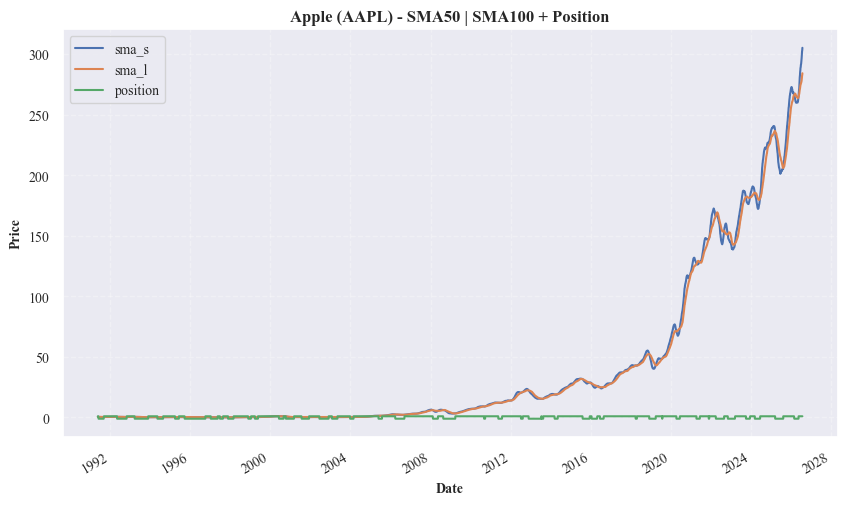

In [202]:
fig, ax = plt.subplots(figsize = (10, 6))
data.loc[:, ['sma_s', 'sma_l', 'position']].plot(ax = ax)
ax.set_title('Apple (AAPL) - SMA{} | SMA{} + Position'.format(sma_s, sma_l), fontweight = 'bold', fontsize = 12)
ax.set_xlabel('Date', fontweight = 'bold', fontsize = 10)
ax.set_ylabel('Price', fontweight = 'bold', fontsize = 10)
ax.legend(fontsize = 10)
ax.tick_params(axis = 'both', labelsize = 10)
ax.grid(True, linestyle = '--', alpha = 0.3)

plt.show()

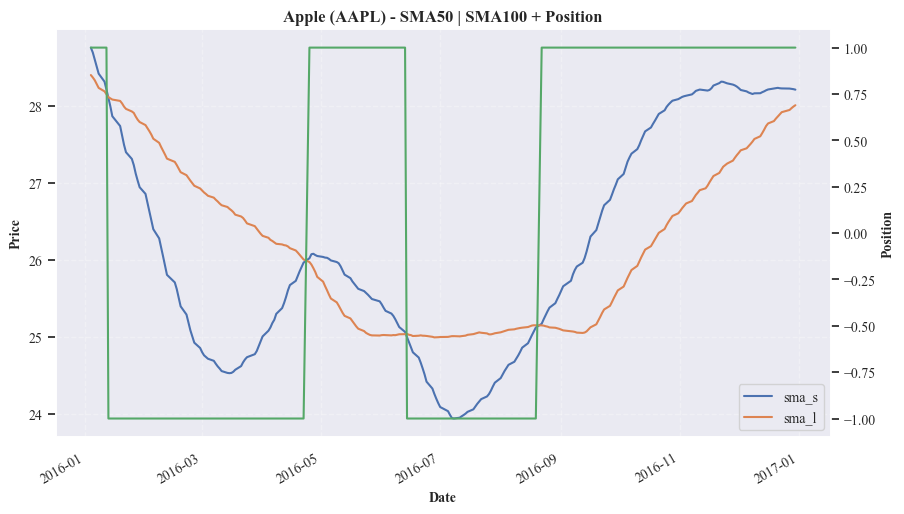

In [208]:
fig, ax = plt.subplots(figsize = (10, 6))
data.loc['2016', ['sma_s', 'sma_l', 'position']].plot(ax = ax, secondary_y = 'position')
ax.set_title('Apple (AAPL) - SMA{} | SMA{} + Position'.format(sma_s, sma_l), fontweight = 'bold', fontsize = 12)
ax.set_xlabel('Date', fontweight = 'bold', fontsize = 10)
ax.set_ylabel('Price', fontweight = 'bold', fontsize = 10)
ax.legend(loc = 'lower right', fontsize = 10)
ax.tick_params(axis = 'y', labelsize = 10)
ax.tick_params(axis = 'x', labelsize = 10)
ax.right_ax.set_ylabel('Position', fontsize = 10, fontweight='bold')
ax.right_ax.tick_params(axis = 'y', labelsize = 10)
ax.grid(True, linestyle = '--', alpha = 0.3)

plt.show()

In [209]:
data['returns_bh'] = np.log(data['Close'].div(data['Close'].shift(1)))
data

,Close,sma_s,sma_l,position,returns_bh
Date,,,,,
1991-05-23,0.402902,0.534420,0.513326,1,NaN
1991-05-24,0.409598,0.530960,0.513538,1,0.016483
1991-05-28,0.410714,0.527344,0.513806,1,0.002721
1991-05-29,0.419643,0.523638,0.514141,1,0.021507
1991-05-30,0.425223,0.519732,0.514531,1,0.013209
...,...,...,...,...,...
2026-07-17,333.739990,302.648400,282.236000,1,0.001439
2026-07-20,326.589996,303.430000,282.780500,1,-0.021657
2026-07-21,327.739990,304.236000,283.315600,1,0.003515


In [210]:
data['strategy'] = data['returns_bh'] * data['position'].shift(1)
data

,Close,sma_s,sma_l,position,returns_bh,strategy
Date,,,,,,
1991-05-23,0.402902,0.534420,0.513326,1,NaN,NaN
1991-05-24,0.409598,0.530960,0.513538,1,0.016483,0.016483
1991-05-28,0.410714,0.527344,0.513806,1,0.002721,0.002721
1991-05-29,0.419643,0.523638,0.514141,1,0.021507,0.021507
1991-05-30,0.425223,0.519732,0.514531,1,0.013209,0.013209
...,...,...,...,...,...,...
2026-07-17,333.739990,302.648400,282.236000,1,0.001439,0.001439
2026-07-20,326.589996,303.430000,282.780500,1,-0.021657,-0.021657
2026-07-21,327.739990,304.236000,283.315600,1,0.003515,0.003515


In [211]:
data.dropna(inplace = True)

In [212]:
data[['returns_bh', 'strategy']].sum()

returns_bh    6.678320
strategy      1.619355
dtype: float64

In [213]:
data[['returns_bh', 'strategy']].sum().apply(np.exp)

returns_bh    794.982358
strategy        5.049833
dtype: float64

In [214]:
data[['returns_bh', 'strategy']].std() * np.sqrt(252)

returns_bh    0.425354
strategy      0.425513
dtype: float64

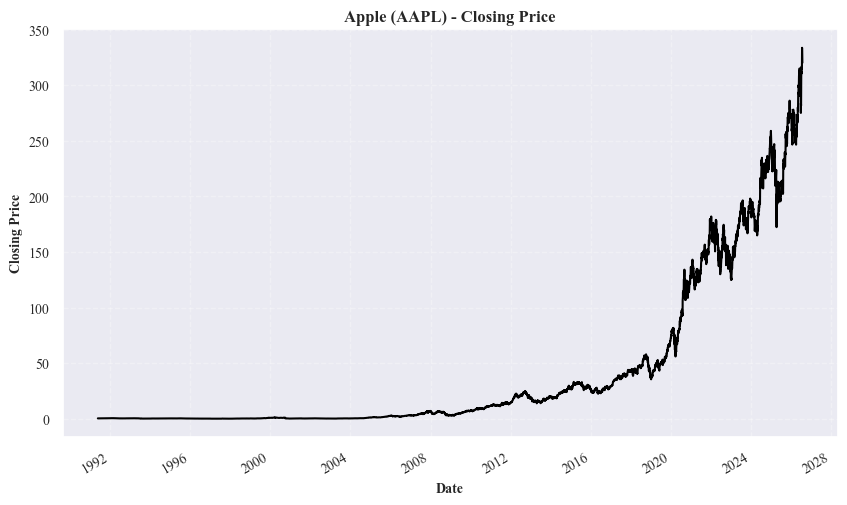

In [216]:
fig, ax = plt.subplots(figsize = (10, 6))
data['Close'].plot(ax = ax, color = 'black')
ax.set_title('Apple (AAPL) - Closing Price', fontweight = 'bold', fontsize = 12)
ax.set_xlabel('Date', fontweight = 'bold', fontsize = 10)
ax.set_ylabel('Closing Price', fontweight = 'bold', fontsize = 10)
ax.tick_params(axis = 'both', labelsize = 10)
ax.grid(True, linestyle = '--', alpha = 0.3)

plt.show()

In [217]:
data['position2'] = np.where(data['sma_s'] > data['sma_l'], 1, 0)
data

,Close,sma_s,sma_l,position,returns_bh,strategy,position2
Date,,,,,,,
1991-05-24,0.409598,0.530960,0.513538,1,0.016483,0.016483,1
1991-05-28,0.410714,0.527344,0.513806,1,0.002721,0.002721,1
1991-05-29,0.419643,0.523638,0.514141,1,0.021507,0.021507,1
1991-05-30,0.425223,0.519732,0.514531,1,0.013209,0.013209,1
1991-05-31,0.419643,0.516027,0.514866,1,-0.013209,-0.013209,1
...,...,...,...,...,...,...,...
2026-07-17,333.739990,302.648400,282.236000,1,0.001439,0.001439,1
2026-07-20,326.589996,303.430000,282.780500,1,-0.021657,-0.021657,1
2026-07-21,327.739990,304.236000,283.315600,1,0.003515,0.003515,1


In [218]:
data['strategy2'] = data['returns_bh'] * data['position2'].shift(1)
data

,Close,sma_s,sma_l,position,returns_bh,strategy,position2,strategy2
Date,,,,,,,,
1991-05-24,0.409598,0.530960,0.513538,1,0.016483,0.016483,1,NaN
1991-05-28,0.410714,0.527344,0.513806,1,0.002721,0.002721,1,0.002721
1991-05-29,0.419643,0.523638,0.514141,1,0.021507,0.021507,1,0.021507
1991-05-30,0.425223,0.519732,0.514531,1,0.013209,0.013209,1,0.013209
1991-05-31,0.419643,0.516027,0.514866,1,-0.013209,-0.013209,1,-0.013209
...,...,...,...,...,...,...,...,...
2026-07-17,333.739990,302.648400,282.236000,1,0.001439,0.001439,1,0.001439
2026-07-20,326.589996,303.430000,282.780500,1,-0.021657,-0.021657,1,-0.021657
2026-07-21,327.739990,304.236000,283.315600,1,0.003515,0.003515,1,0.003515


In [219]:
data.dropna(inplace = True)

In [220]:
data[['returns_bh', 'strategy2']].sum()

returns_bh    6.661837
strategy2     4.132355
dtype: float64

In [221]:
data[['returns_bh', 'strategy2']].sum().apply(np.exp)

returns_bh    781.986224
strategy2      62.324510
dtype: float64

In [222]:
data[['returns_bh', 'strategy2']].std() * np.sqrt(252)

returns_bh    0.425370
strategy2     0.327799
dtype: float64

In [225]:
data[['strategy', 'strategy2']].std() * np.sqrt(252)

strategy     0.425528
strategy2    0.327799
dtype: float64

In [248]:
def test_strategy(stock, start_date, end_date, SMA):
    
    df = yf.download(stock, start = start_date, end = end_date, auto_adjust = False)
    data = df['Close'].copy()
    data.columns = ['Close']
    data['returns'] = np.log(data['Close'].div(data['Close'].shift(1)))
    data['SMA_S'] = data['Close'].rolling(int(SMA[0])).mean()
    data['SMA_L'] = data['Close'].rolling(int(SMA[1])).mean()
    data.dropna(inplace = True)
    data['position'] = np.where(data['SMA_S'] > data['SMA_L'], 1, -1)
    data['strategy'] = data['returns'] * data['position'].shift(1)
    data.dropna(inplace = True)
    returns = np.exp(data['strategy'].sum())
    std = data['strategy'].std() * np.sqrt(252)
    
    print(f'Returns for {stock}: {returns}'), 
    print(f'Standard Deviation for {stock}: {std}')

In [249]:
test_strategy('MSFT', '2000-01-01', datetime.today().strftime('%Y-%m-%d'), (50, 200))

[*********************100%***********************]  1 of 1 completed

Returns for MSFT: 0.8034260412056412
Standard Deviation for MSFT: 0.2928860196252628


In [250]:
test_strategy('AAPL', '2000-01-01', datetime.today().strftime('%Y-%m-%d'), (50, 200))

[*********************100%***********************]  1 of 1 completed

Returns for AAPL: 19.598358195287183
Standard Deviation for AAPL: 0.35417814547131055


In [251]:
test_strategy('AMZN', '2000-01-01', datetime.today().strftime('%Y-%m-%d'), (50, 200))

[*********************100%***********************]  1 of 1 completed

Returns for AMZN: 9.680122900738665
Standard Deviation for AMZN: 0.45873162172920934


In [252]:
test_strategy('TSLA', '2000-01-01', datetime.today().strftime('%Y-%m-%d'), (50, 200))

[*********************100%***********************]  1 of 1 completed

Returns for TSLA: 2.7189434573213904
Standard Deviation for TSLA: 0.5659188843177605


In [253]:
test_strategy('NFLX', '2000-01-01', datetime.today().strftime('%Y-%m-%d'), (50, 200))

[*********************100%***********************]  1 of 1 completed

Returns for NFLX: 272.88242608366585
Standard Deviation for NFLX: 0.5277163545582968


In [277]:
class SMABacktester():
    
    def __init__(self, symbol, SMA_S, SMA_L, start_date, end_date):

        self.symbol = symbol
        self.SMA_S = SMA_S
        self.SMA_L = SMA_L
        self.start_date = start_date
        self.end_date = end_date
        self.results = None
        self.get_data()

    def get_data(self):
    
        df = yf.download(self.symbol, start = self.start_date, end = self.end_date, auto_adjust = False)
        data = df['Close'].copy()
        data.columns = ['Close']
        data['returns'] = np.log(data['Close'].div(data['Close'].shift(1)))
        data['SMA_S'] = data['Close'].rolling(self.SMA_S).mean()
        data['SMA_L'] = data['Close'].rolling(self.SMA_L).mean()
        data.dropna(inplace = True)
        self.data2 = data

        return data

    def test_results(self):
        
        data = self.data2.copy().dropna()
        data['position'] = np.where(data['SMA_S'] > data['SMA_L'], 1, -1)
        data['strategy'] = data['returns'] * data['position'].shift(1)
        data.dropna(inplace = True)
        data['returns_bh'] = data['returns'].cumsum().apply(np.exp)
        data['returns_strategy'] = data['strategy'].cumsum().apply(np.exp)
        performance = data['returns_strategy'].iloc[-1]
        outperformance = performance - data['returns_bh'].iloc[-1]
        self.results = data
        returns = np.exp(data['strategy'].sum())
        std = data['strategy'].std() * np.sqrt(252)
    
        print(f'Performance for {self.symbol}: {round(performance, 6)}'), 
        print(f'Outperformance Deviation for {self.symbol}: {round(outperformance, 6)}')

    def plot_results(self):

        if self.results is None:
            print('Run the test please')
        else:
            title = '{} | SMA_S = {} | SMA_L = {}'.format(self.symbol, self.SMA_S, self.SMA_L)
            fig, ax = plt.subplots(figsize = (10, 6))
            self.results[['returns_bh', 'returns_strategy']].plot(ax = ax)
            ax.set_title(title, fontweight = 'bold', fontsize = 12)
            ax.set_xlabel('Date', fontweight = 'bold', fontsize = 10)
            ax.set_ylabel('Returns', fontweight = 'bold', fontsize = 10)
            ax.legend(fontsize = 10)
            ax.tick_params(axis = 'both', labelsize = 10)
            ax.grid(True, linestyle = '--', alpha = 0.3)
            plt.show()

In [278]:
tester = SMABacktester('MSFT', 50, 100, '2000-01-01', datetime.today().strftime('%Y-%m-%d'))

[*********************100%***********************]  1 of 1 completed


In [279]:
tester.test_results()

Performance for MSFT: 0.723911
Outperformance Deviation for MSFT: -11.183505


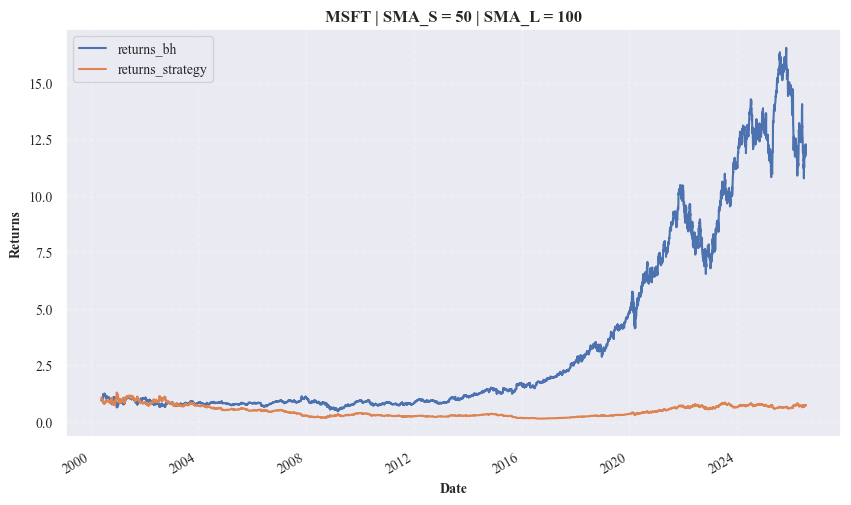

In [280]:
tester.plot_results()

In [281]:
tester = SMABacktester('AAPL', 50, 100, '2000-01-01', datetime.today().strftime('%Y-%m-%d'))

[*********************100%***********************]  1 of 1 completed


In [282]:
tester.test_results()

Performance for AAPL: 7.625992
Outperformance Deviation for AAPL: -408.621328


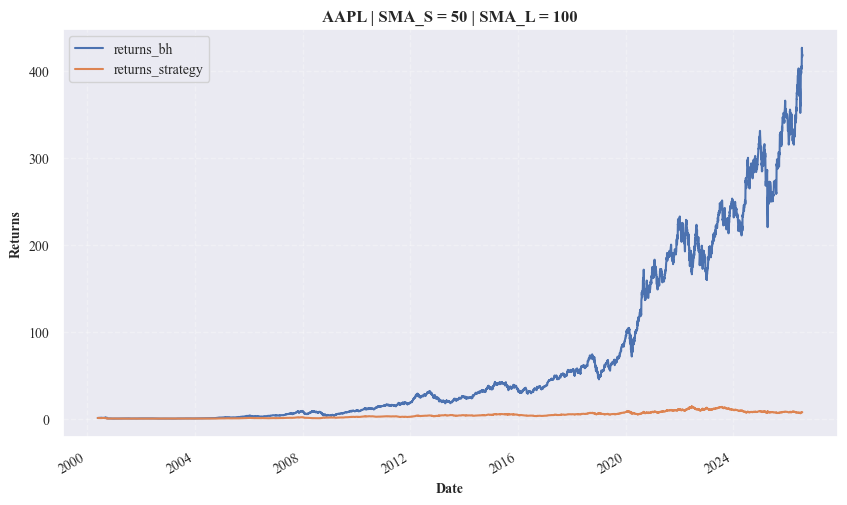

In [283]:
tester.plot_results()

In [284]:
tester = SMABacktester('AMZN', 50, 100, '2000-01-01', datetime.today().strftime('%Y-%m-%d'))

[*********************100%***********************]  1 of 1 completed


In [285]:
tester.test_results()

Performance for AMZN: 11.163715
Outperformance Deviation for AMZN: -89.675417


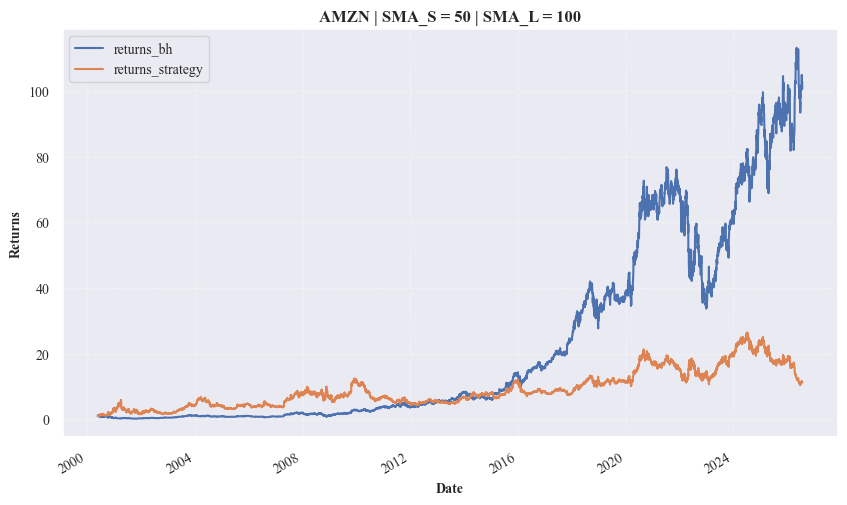

In [286]:
tester.plot_results()

In [287]:
tester = SMABacktester('TSLA', 50, 100, '2000-01-01', datetime.today().strftime('%Y-%m-%d'))

[*********************100%***********************]  1 of 1 completed


In [288]:
tester.test_results()

Performance for TSLA: 14.059758
Outperformance Deviation for TSLA: -176.179315


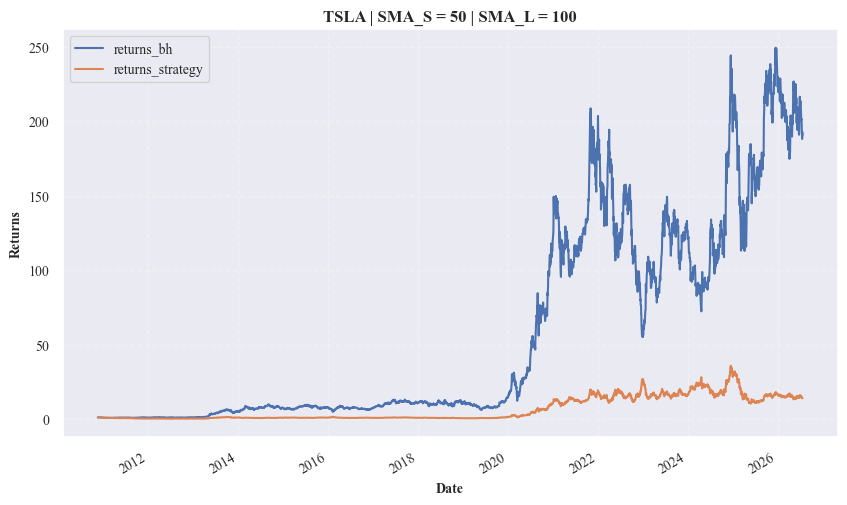

In [289]:
tester.plot_results()

In [290]:
tester = SMABacktester('NFLX', 50, 100, '2000-01-01', datetime.today().strftime('%Y-%m-%d'))

[*********************100%***********************]  1 of 1 completed


In [291]:
tester.test_results()

Performance for NFLX: 524.500711
Outperformance Deviation for NFLX: -758.136035


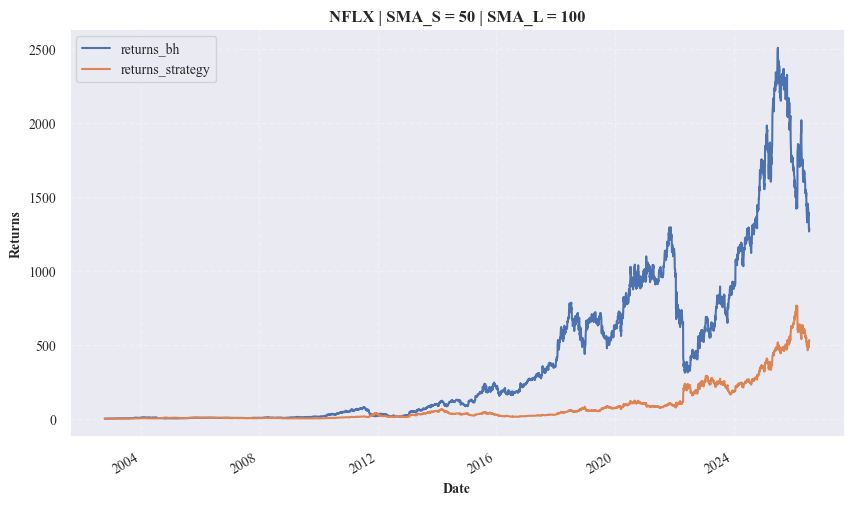

In [292]:
tester.plot_results()

In [293]:
from backtester import SMABacktester